# 📈 Time Series & Forecasting Practical Handbook in Python

---

Welcome to the **Time Series & Forecasting Handbook** : an intermediate-level, hands-on guide covering everything from raw time series concepts to deep learning and production-grade forecasting tools.

### 📚 Table of Contents
1. Introduction to Time Series
2. Loading & Visualising Time Series Data
3. Time Series Decomposition
4. Stationarity & Statistical Tests
5. Classical Forecasting / Moving Average & Exponential Smoothing
6. ARIMA & SARIMA Models
7. Feature Engineering for Time Series
8. Machine Learning for Forecasting
9. LSTM Deep Learning Forecasting
10. Facebook Prophet
11. Model Evaluation & Comparison
12. Mini Project : End-to-End Forecasting Pipeline

---
> **Level:** Intermediate  
> **Prerequisites:** Basic Python, Pandas, NumPy, some ML familiarity  
> Run the **installation cell** below before anything else.

In [16]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn prophet torch --quiet

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global plot style
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})



---
## Section 1: Introduction to Time Series

### What is a Time Series?
A **time series** is a sequence of data points indexed in chronological order. Unlike cross-sectional data, observations are **not independent**  each value is related to its past.

### Key Components
| Component | Description | Example |
|---|---|---|
| **Trend** | Long-term upward or downward movement | Rising stock price |
| **Seasonality** | Regular, periodic fluctuations | Holiday retail sales |
| **Cyclicity** | Irregular, longer-term fluctuations | Business cycles |
| **Residual / Noise** | Random variation after removing other components | Unexplained spikes |

### Forecasting Approaches
```
Classical Stats          Machine Learning        Deep Learning
─────────────────        ──────────────────      ──────────────────
Moving Average           Linear Regression       LSTM / GRU
Exponential Smoothing    Random Forest           Temporal Fusion
ARIMA / SARIMA           XGBoost                 Transformer
                                                 N-BEATS

                   Facebook Prophet
          (hybrid: additive decomposition model)
```

### When to use what?
- **ARIMA** : Stationary, univariate, short series, high interpretability needed
- **Prophet** : Business time series with strong seasonality, missing data, holiday effects
- **LSTM** : Long series, complex non-linear patterns, multivariate inputs
- **ML models** : Many features available, non-linear relationships

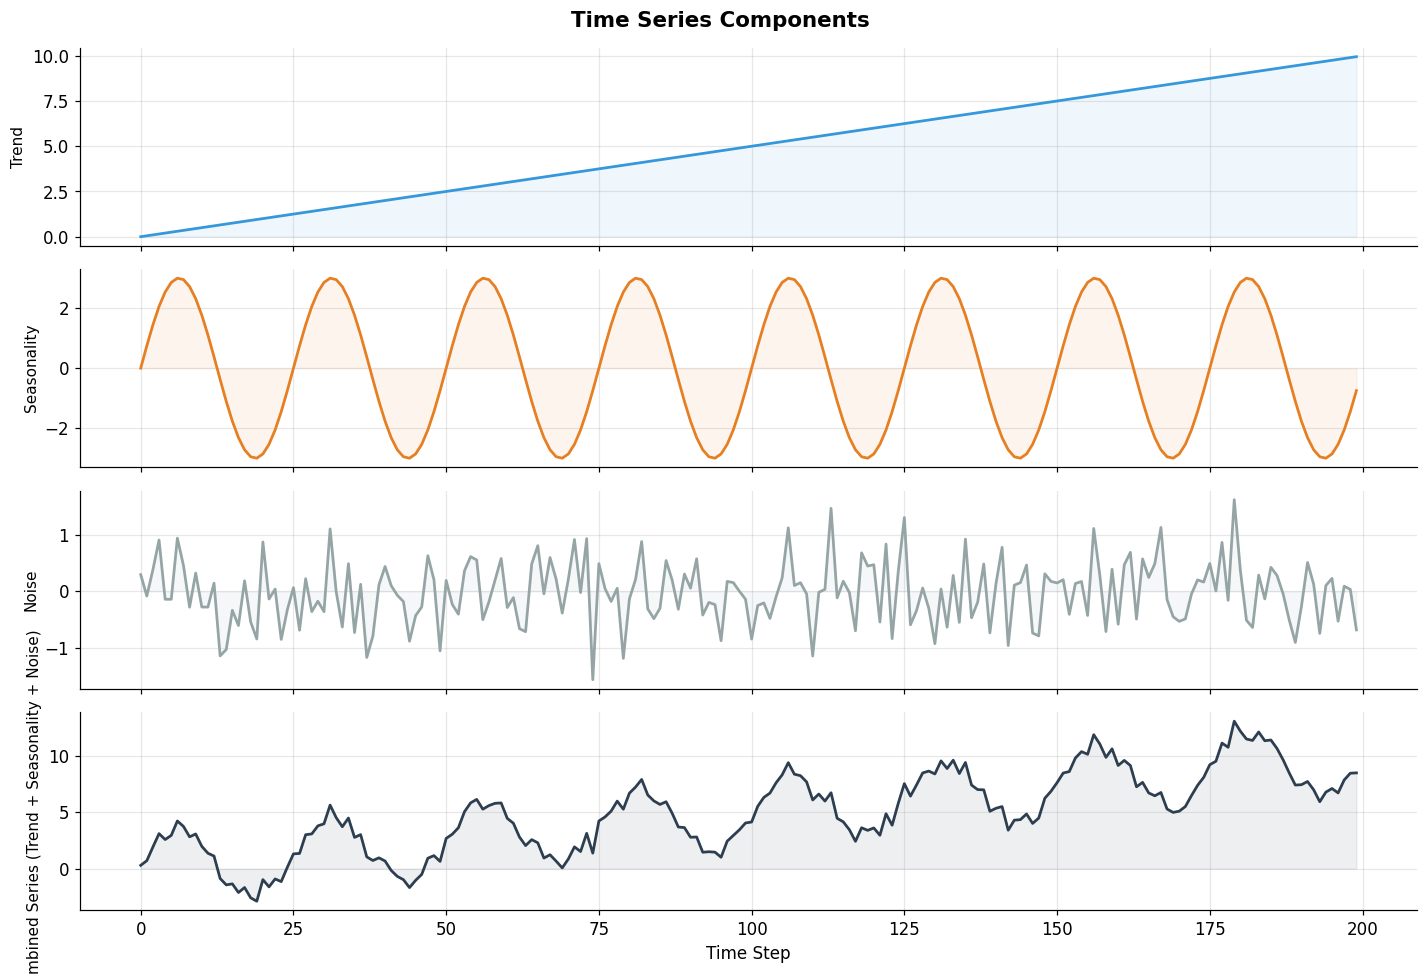

In [17]:
# section 1 — Visualising the core time series components

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
t = np.arange(0, 200)

trend      = 0.05 * t                                 # upward linear trend
seasonality = 3 * np.sin(2 * np.pi * t / 25)          # periodic pattern
noise      = np.random.normal(0, 0.6, len(t))          # random noise
series     = trend + seasonality + noise               # combined signal

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
components = [
    (trend,      'Trend',       '#3498db'),
    (seasonality,'Seasonality', '#e67e22'),
    (noise,      'Noise',       '#95a5a6'),
    (series,     'Combined Series (Trend + Seasonality + Noise)', '#2c3e50'),
]
for ax, (data, label, color) in zip(axes, components):
    ax.plot(t, data, color=color, linewidth=1.8)
    ax.set_ylabel(label, fontsize=10)
    ax.fill_between(t, data, alpha=0.08, color=color)

axes[-1].set_xlabel('Time Step')
fig.suptitle('Time Series Components', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2: Loading & Visualising Time Series Data

We'll generate a **realistic synthetic dataset** representing monthly retail sales over 5 years with trend, seasonality, and noise. This mirrors real-world business forecasting scenarios.

> In practice you'd load a CSV with `pd.read_csv('data.csv', parse_dates=['date'], index_col='date')`

In [18]:
# section 2 — Build & Explore the Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2024)

#  Generate 5 years of daily data 
dates = pd.date_range(start='2019-01-01', end='2023-12-31', freq='D')
n     = len(dates)

# Components
trend       = np.linspace(100, 180, n)                          # growth trend
weekly_seas = 15 * np.sin(2 * np.pi * np.arange(n) / 7)        # weekly cycle
yearly_seas = 30 * np.sin(2 * np.pi * np.arange(n) / 365.25)   # yearly cycle
holiday_bump = np.zeros(n)

# Add holiday spikes (Dec each year)
for year in range(2019, 2024):
    dec_mask = (pd.Series(dates).dt.year == year) & (pd.Series(dates).dt.month == 12)
    holiday_bump[dec_mask.values] = np.random.uniform(20, 40)

noise  = np.random.normal(0, 5, n)
sales  = trend + weekly_seas + yearly_seas + holiday_bump + noise
sales  = np.clip(sales, 50, None)   # no negative sales

df = pd.DataFrame({'date': dates, 'sales': sales.round(2)})
df.set_index('date', inplace=True)

# Also create a monthly resampled version for slower models
df_monthly = df.resample('ME').mean().round(2)

print(f' Dataset: {len(df)} daily records ({df.index.min().date()} → {df.index.max().date()})')
print(f'   Monthly version: {len(df_monthly)} records')
print(f'\nBasic Statistics:')
print(df['sales'].describe().round(2))

 Dataset: 1826 daily records (2019-01-01 → 2023-12-31)
   Monthly version: 60 records

Basic Statistics:
count    1826.00
mean      142.33
std        31.87
min        60.16
25%       119.27
50%       142.93
75%       165.67
max       227.81
Name: sales, dtype: float64


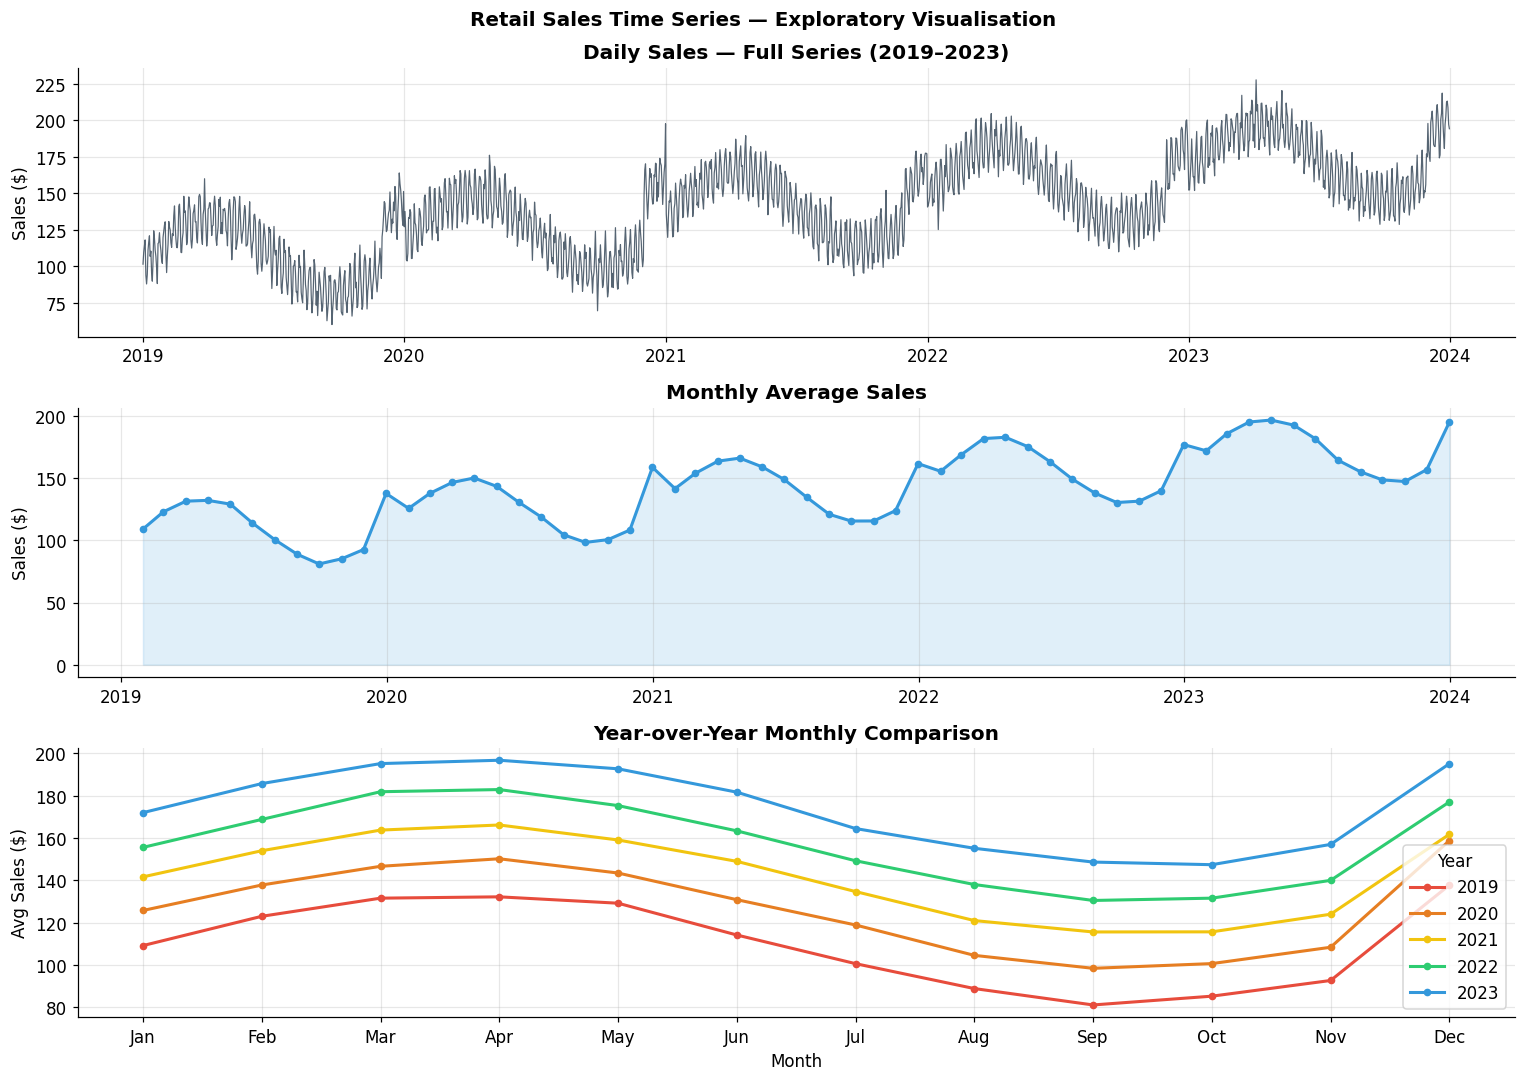

In [19]:
#Visualise the full series
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Full daily series
axes[0].plot(df.index, df['sales'], color='#2c3e50', linewidth=0.8, alpha=0.8)
axes[0].set_title('Daily Sales — Full Series (2019–2023)', fontweight='bold')
axes[0].set_ylabel('Sales ($)')

# Monthly resampled
axes[1].plot(df_monthly.index, df_monthly['sales'], color='#3498db',
             linewidth=2, marker='o', markersize=4)
axes[1].fill_between(df_monthly.index, df_monthly['sales'], alpha=0.15, color='#3498db')
axes[1].set_title('Monthly Average Sales', fontweight='bold')
axes[1].set_ylabel('Sales ($)')

# Year-over-year comparison
df['year']  = df.index.year
df['month'] = df.index.month
monthly_pivot = df.groupby(['year', 'month'])['sales'].mean().unstack(level=0)
colors_yoy = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
for (year, color) in zip(monthly_pivot.columns, colors_yoy):
    axes[2].plot(monthly_pivot.index, monthly_pivot[year],
                 label=str(year), color=color, linewidth=2, marker='o', markersize=4)
axes[2].set_title('Year-over-Year Monthly Comparison', fontweight='bold')
axes[2].set_ylabel('Avg Sales ($)')
axes[2].set_xlabel('Month')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[2].legend(title='Year')

# Clean up helper columns
df.drop(columns=['year', 'month'], inplace=True)

plt.suptitle('Retail Sales Time Series — Exploratory Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

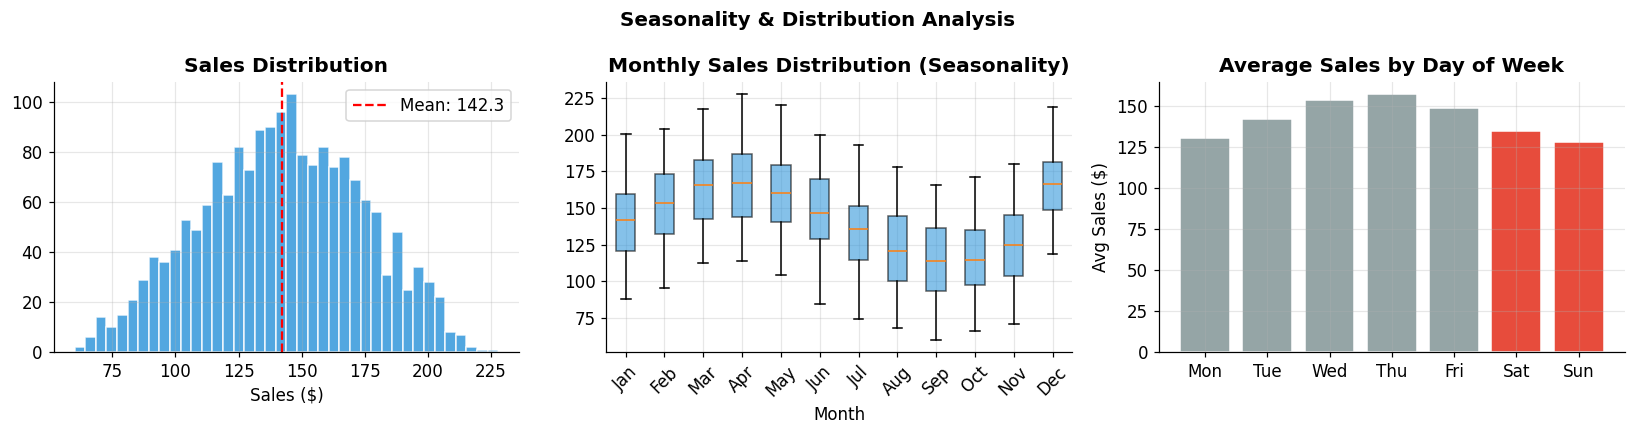

In [20]:
# Distribution & Seasonality Patterns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['sales'], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(df['sales'].mean(), color='red', linestyle='--', label=f'Mean: {df["sales"].mean():.1f}')
axes[0].set_title('Sales Distribution', fontweight='bold')
axes[0].set_xlabel('Sales ($)')
axes[0].legend()

# Boxplot by month
df['month_name'] = df.index.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)
month_data = [df[df['month_name']==m]['sales'].values for m in month_order]
bp = axes[1].boxplot(month_data, labels=month_order, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.6)
axes[1].set_title('Monthly Sales Distribution (Seasonality)', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)

# Average by day of week
df['dow'] = df.index.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg   = df.groupby('dow')['sales'].mean().reindex(dow_order)
dow_colors = ['#95a5a6']*5 + ['#e74c3c', '#e74c3c']   # highlight weekends
axes[2].bar(range(7), dow_avg.values, color=dow_colors, edgecolor='white')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[2].set_title('Average Sales by Day of Week', fontweight='bold')
axes[2].set_ylabel('Avg Sales ($)')

df.drop(columns=['month_name','dow'], inplace=True)
plt.suptitle('Seasonality & Distribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3: Time Series Decomposition

**Decomposition** separates a time series into its underlying components to understand structure and improve forecasting.

### Additive vs Multiplicative
| Model | Formula | Use When |
|---|---|---|
| **Additive** | `y = Trend + Seasonality + Residual` | Seasonal variation is constant |
| **Multiplicative** | `y = Trend × Seasonality × Residual` | Seasonal variation grows with trend |

We use `statsmodels.seasonal_decompose` for classical decomposition and STL for more robust results.

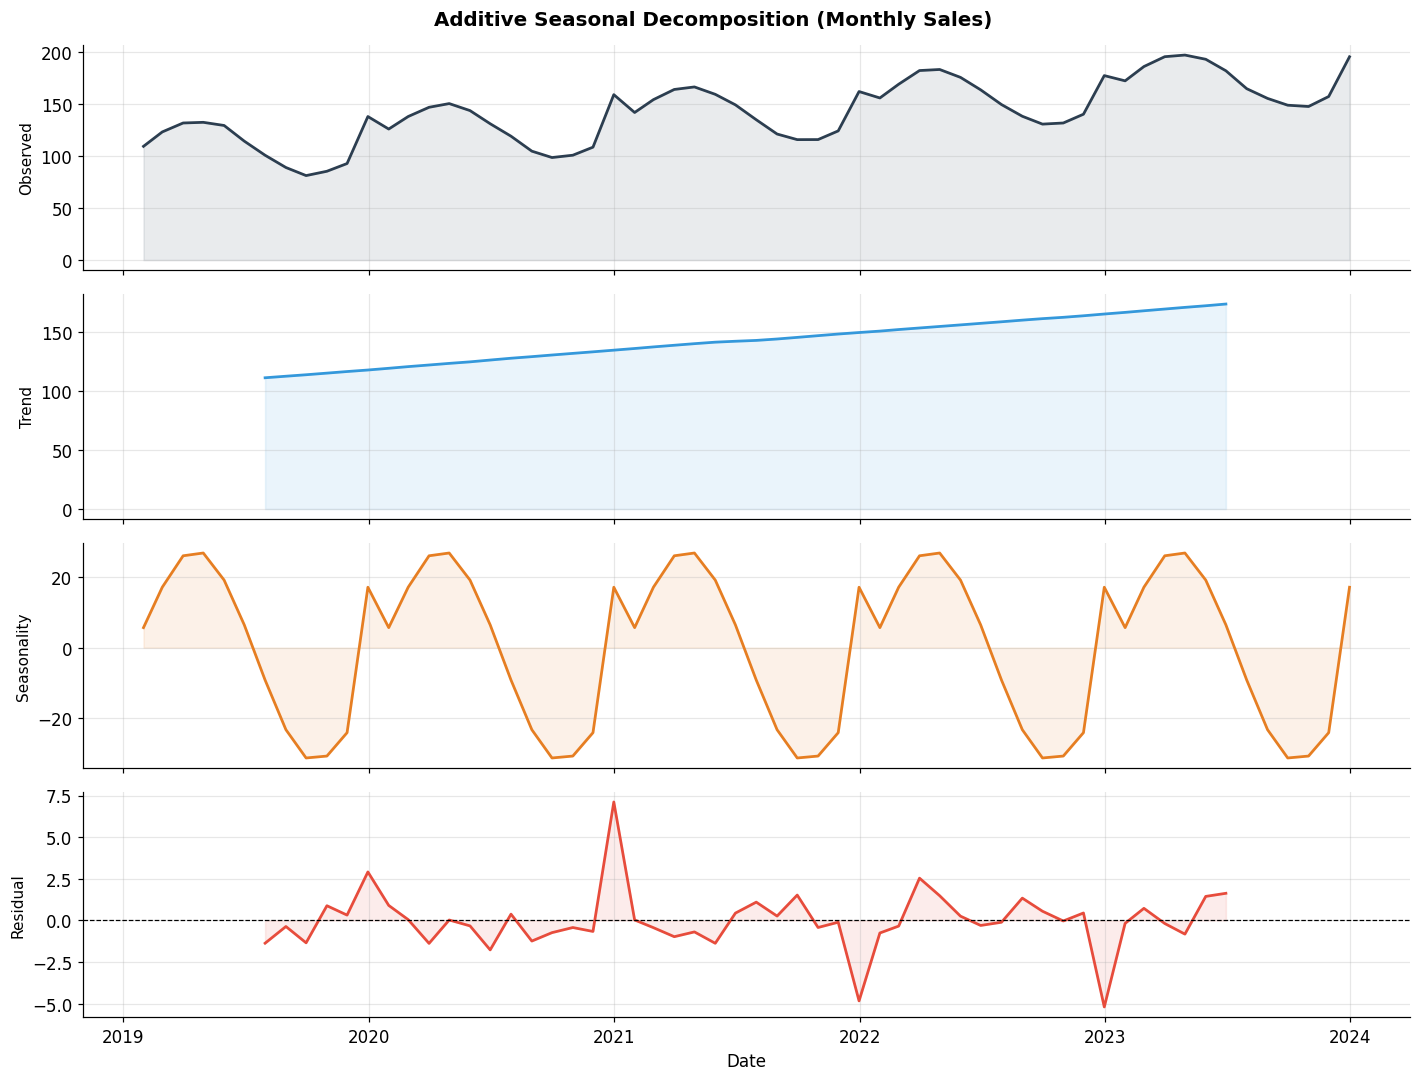

 Component Strength:
   Trend    contribution: 38.2%
   Seasonal contribution: 53.4%
   Residual contribution: 0.4%


In [21]:
# Section 3 — Seasonal Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose, STL

# Use monthly data for cleaner decomposition
decomp = seasonal_decompose(df_monthly['sales'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
components = [
    (df_monthly['sales'],  'Observed',    '#2c3e50'),
    (decomp.trend,         'Trend',       '#3498db'),
    (decomp.seasonal,      'Seasonality', '#e67e22'),
    (decomp.resid,         'Residual',    '#e74c3c'),
]
for ax, (data, label, color) in zip(axes, components):
    ax.plot(data.index, data, color=color, linewidth=1.8)
    if label == 'Residual':
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_ylabel(label, fontsize=10)
    ax.fill_between(data.index, data, alpha=0.1, color=color)

axes[-1].set_xlabel('Date')
fig.suptitle('Additive Seasonal Decomposition (Monthly Sales)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics for each component
print(' Component Strength:')
total_var   = df_monthly['sales'].var()
trend_var   = decomp.trend.dropna().var()
seas_var    = decomp.seasonal.var()
resid_var   = decomp.resid.dropna().var()
print(f'   Trend    contribution: {trend_var/total_var*100:.1f}%')
print(f'   Seasonal contribution: {seas_var/total_var*100:.1f}%')
print(f'   Residual contribution: {resid_var/total_var*100:.1f}%')

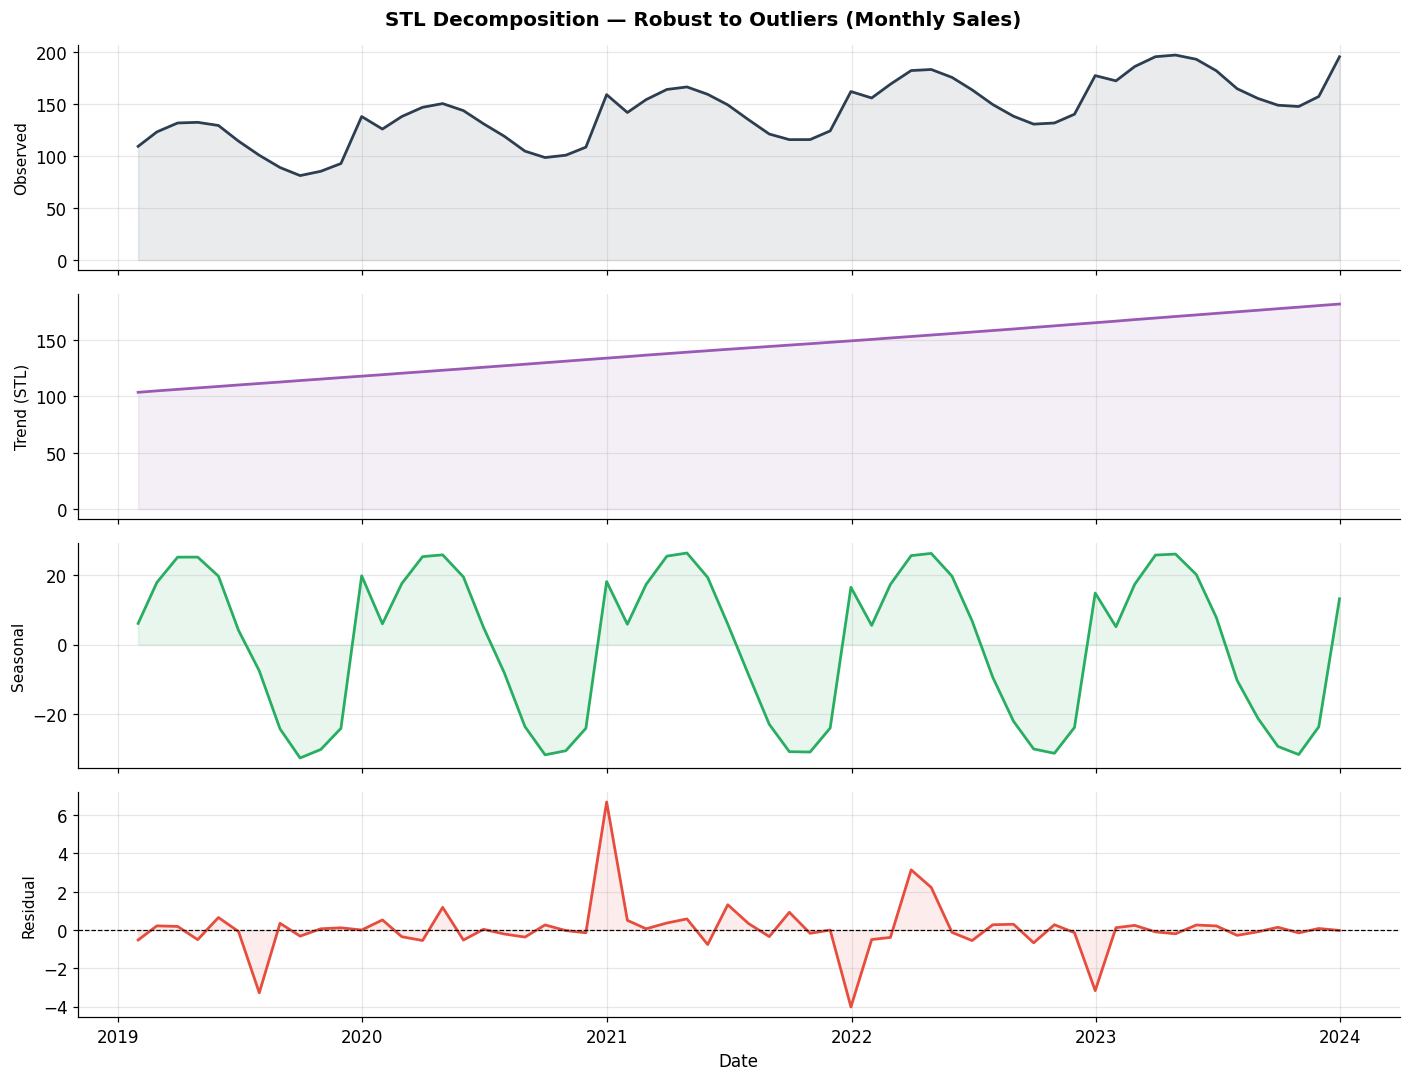

In [22]:
#  STL Decomposition (more robust to outliers)
stl = STL(df_monthly['sales'], period=12, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
stl_components = [
    (stl_result.observed,  'Observed',    '#2c3e50'),
    (stl_result.trend,     'Trend (STL)', '#9b59b6'),
    (stl_result.seasonal,  'Seasonal',    '#27ae60'),
    (stl_result.resid,     'Residual',    '#e74c3c'),
]
for ax, (data, label, color) in zip(axes, stl_components):
    ax.plot(data.index, data, color=color, linewidth=1.8)
    if label == 'Residual':
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_ylabel(label, fontsize=10)
    ax.fill_between(data.index, data, alpha=0.1, color=color)

axes[-1].set_xlabel('Date')
fig.suptitle('STL Decomposition — Robust to Outliers (Monthly Sales)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4: Stationarity & Statistical Tests

### What is Stationarity?
A time series is **stationary** if its statistical properties (mean, variance, autocorrelation) do not change over time. Most classical forecasting models (like ARIMA) **require stationarity**.

### How to achieve stationarity?
1. **Differencing** : subtract previous value: `y'_t = y_t - y_{t-1}`
2. **Log transform** : stabilises variance: `y' = log(y)`
3. **Detrending** : remove polynomial trend

### Tests
| Test | Null Hypothesis | Stationary if |
|---|---|---|
| **ADF** (Augmented Dickey-Fuller) | Series has a unit root (non-stationary) | p-value < 0.05 |
| **KPSS** | Series is stationary | p-value > 0.05 |

In [23]:
# Section 4 — Stationarity Tests & Differencing

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def run_stationarity_tests(series, label):
    
    # ADF test
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna())
    # KPSS test
    kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')

    adf_result  = ' Stationary' if adf_p  < 0.05 else ' Non-Stationary'
    kpss_result = ' Stationary' if kpss_p > 0.05 else ' Non-Stationary'

    print(f'\n── {label} ──')
    print(f'  ADF  test: stat={adf_stat:.4f},  p={adf_p:.4f}  → {adf_result}')
    print(f'  KPSS test: stat={kpss_stat:.4f}, p={kpss_p:.4f}  → {kpss_result}')
    return adf_p, kpss_p

# Original series
run_stationarity_tests(df_monthly['sales'], 'Original Monthly Sales')

# First differencing
df_monthly['sales_diff1'] = df_monthly['sales'].diff()
run_stationarity_tests(df_monthly['sales_diff1'].dropna(), '1st Difference')

# Seasonal differencing (lag 12)
df_monthly['sales_diff12'] = df_monthly['sales'].diff(12)
run_stationarity_tests(df_monthly['sales_diff12'].dropna(), 'Seasonal Difference (lag=12)')


── Original Monthly Sales ──
  ADF  test: stat=0.1046,  p=0.9664  →  Non-Stationary
  KPSS test: stat=0.8397, p=0.0100  →  Non-Stationary

── 1st Difference ──
  ADF  test: stat=-34.9172,  p=0.0000  →  Stationary
  KPSS test: stat=0.0291, p=0.1000  →  Stationary

── Seasonal Difference (lag=12) ──
  ADF  test: stat=-5.9964,  p=0.0000  →  Stationary
  KPSS test: stat=0.1211, p=0.1000  →  Stationary


(np.float64(1.6979712140119163e-07), np.float64(0.1))

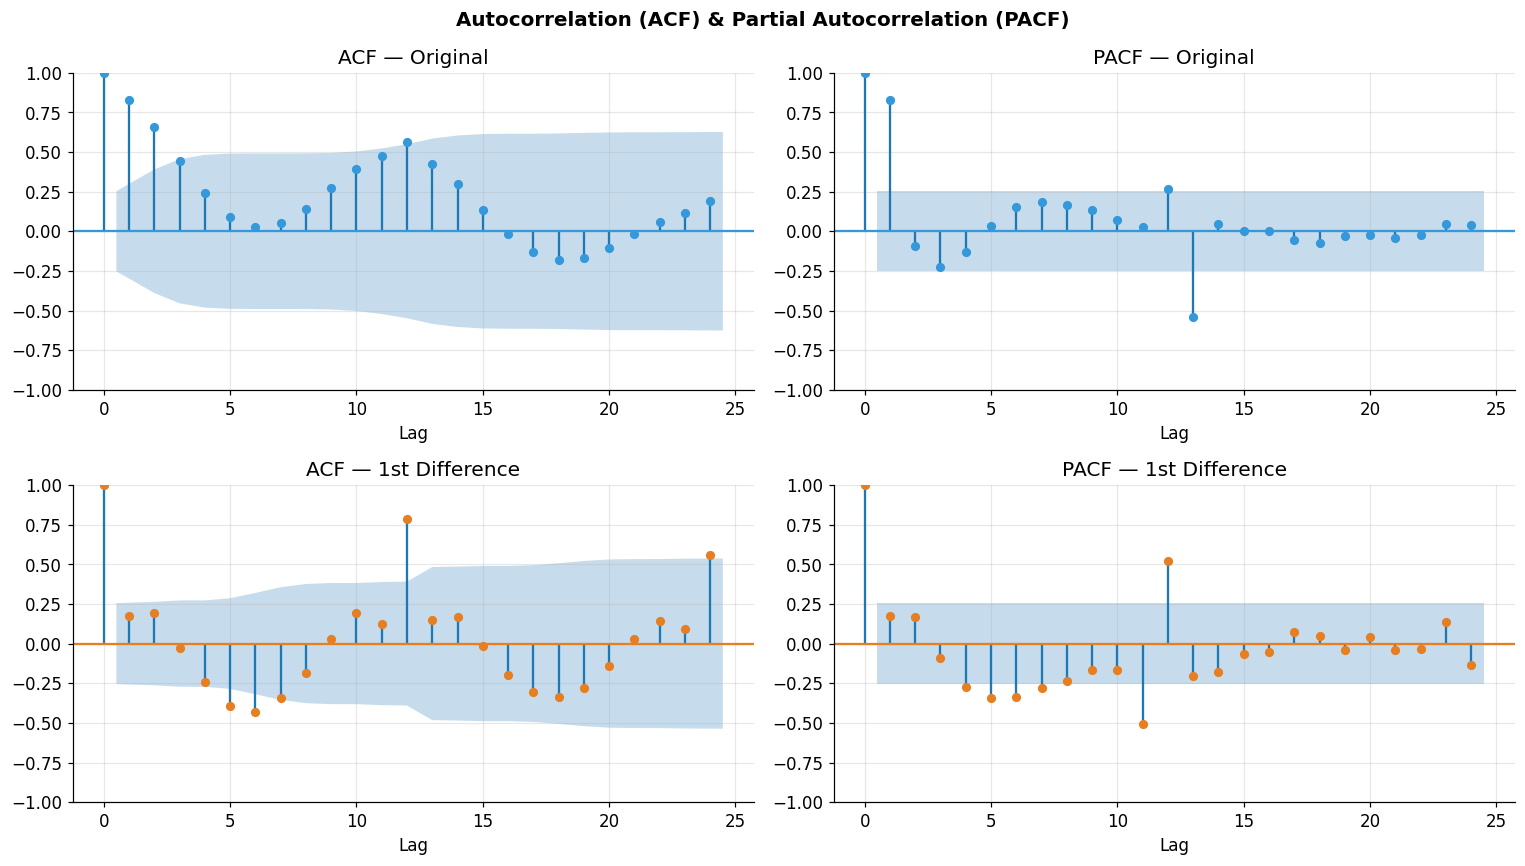

In [24]:
# ACF  → helps determine the MA(q) order
# PACF → helps determine the AR(p) order

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

series_orig = df_monthly['sales']
series_diff = df_monthly['sales_diff1'].dropna()

plot_acf(series_orig,  lags=24, ax=axes[0, 0], color='#3498db', title='ACF — Original')
plot_pacf(series_orig, lags=24, ax=axes[0, 1], color='#3498db', title='PACF — Original')
plot_acf(series_diff,  lags=24, ax=axes[1, 0], color='#e67e22', title='ACF — 1st Difference')
plot_pacf(series_diff, lags=24, ax=axes[1, 1], color='#e67e22', title='PACF — 1st Difference')

for ax in axes.flat:
    ax.set_xlabel('Lag')

fig.suptitle('Autocorrelation (ACF) & Partial Autocorrelation (PACF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



---
## Section 5: Classical Forecasting / Moving Averages & Exponential Smoothing

### Simple & Weighted Moving Averages
A **moving average** smooths a series by averaging over a sliding window, removing short-term noise.

### Exponential Smoothing
Gives **exponentially decreasing weights** to past observations. More recent data matters more.

| Method | Description |
|---|---|
| **Simple Exponential Smoothing (SES)** | No trend or seasonality |
| **Holt's Linear (Double ES)** | Handles trend |
| **Holt-Winters (Triple ES)** | Handles trend + seasonality |

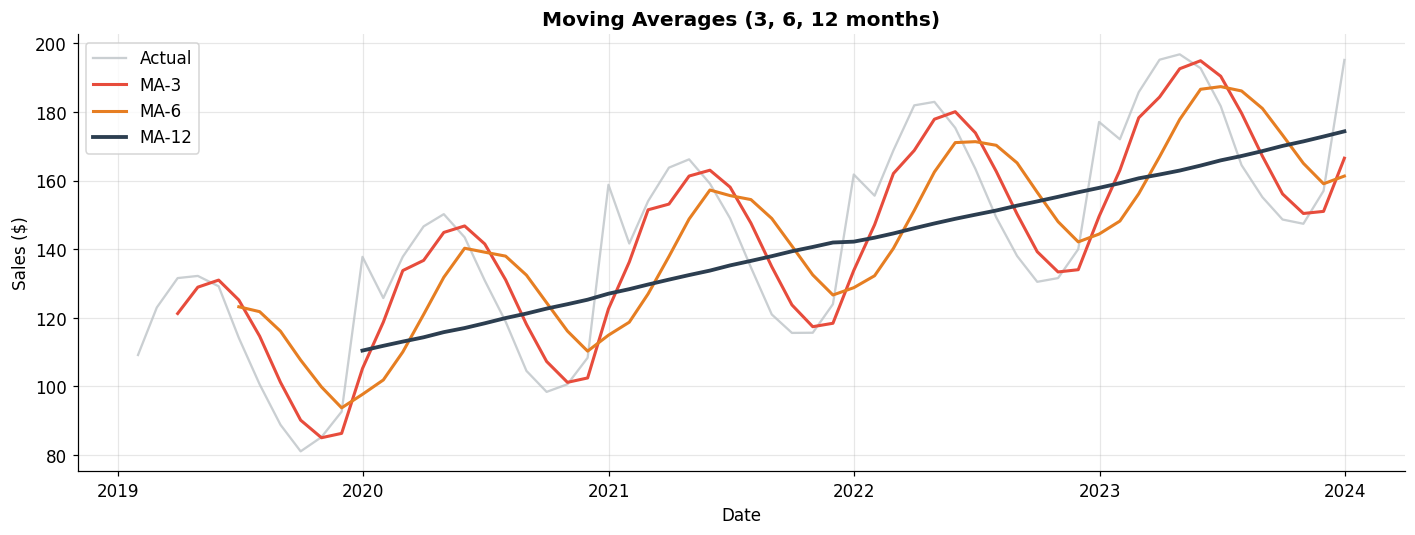

In [25]:
# Section 5 — Moving Averages & Exponential Smoothing

from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Moving Averages
df_monthly['MA_3']  = df_monthly['sales'].rolling(window=3).mean()
df_monthly['MA_6']  = df_monthly['sales'].rolling(window=6).mean()
df_monthly['MA_12'] = df_monthly['sales'].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_monthly['sales'],  color='#bdc3c7', linewidth=1.5, label='Actual', alpha=0.8)
ax.plot(df_monthly['MA_3'],   color='#e74c3c', linewidth=2,   label='MA-3')
ax.plot(df_monthly['MA_6'],   color='#e67e22', linewidth=2,   label='MA-6')
ax.plot(df_monthly['MA_12'],  color='#2c3e50', linewidth=2.5, label='MA-12')
ax.set_title('Moving Averages (3, 6, 12 months)', fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

 Holt-Winters Performance:
   MAE  = 1.42
   RMSE = 1.82
   MAPE = 0.83%


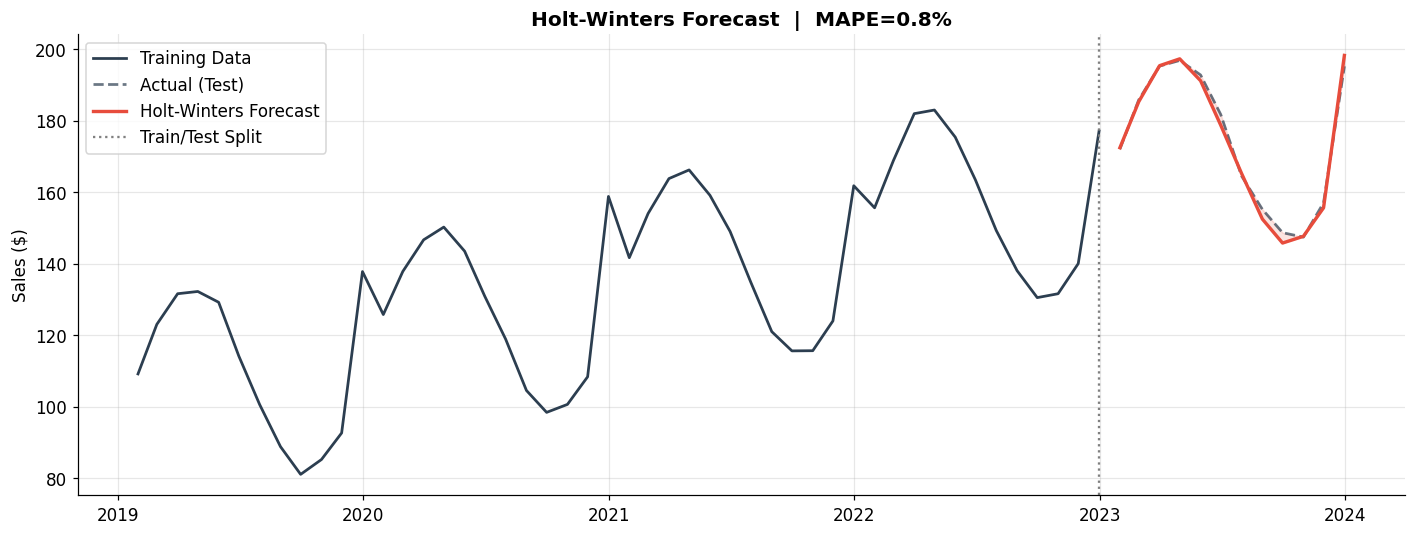

In [26]:
# Holt-Winters Exponential Smoothing 
# Train on 80%, test on last 20%
train_size  = int(len(df_monthly) * 0.8)
train_hw    = df_monthly['sales'][:train_size]
test_hw     = df_monthly['sales'][train_size:]

# Fit Holt-Winters additive model
hw_model = ExponentialSmoothing(
    train_hw,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

hw_forecast = hw_model.forecast(len(test_hw))

mae  = mean_absolute_error(test_hw, hw_forecast)
rmse = np.sqrt(mean_squared_error(test_hw, hw_forecast))
mape = (np.abs((test_hw.values - hw_forecast.values) / test_hw.values)).mean() * 100

print(f' Holt-Winters Performance:')
print(f'   MAE  = {mae:.2f}')
print(f'   RMSE = {rmse:.2f}')
print(f'   MAPE = {mape:.2f}%')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_hw.index, train_hw,           color='#2c3e50', linewidth=1.8, label='Training Data')
ax.plot(test_hw.index,  test_hw,            color='#2c3e50', linewidth=1.8, linestyle='--', label='Actual (Test)', alpha=0.7)
ax.plot(hw_forecast.index, hw_forecast,     color='#e74c3c', linewidth=2.2, label='Holt-Winters Forecast')
ax.axvline(train_hw.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Train/Test Split')
ax.fill_between(test_hw.index, test_hw, hw_forecast, alpha=0.15, color='#e74c3c')
ax.set_title(f'Holt-Winters Forecast  |  MAPE={mape:.1f}%', fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 6: ARIMA & SARIMA Models

**ARIMA(p, d, q)**  AutoRegressive Integrated Moving Average

| Parameter | Meaning | How to determine |
|---|---|---|
| **p** | AR order — how many past values to use | PACF plot (lag where it cuts off) |
| **d** | Differencing order — to achieve stationarity | ADF test |
| **q** | MA order — size of moving average window | ACF plot |

**SARIMA(p,d,q)(P,D,Q,m)** adds seasonal AR and MA components:
- `m` = seasonal period (12 for monthly data)
- `P, D, Q` = seasonal counterparts of p, d, q

> We'll use `auto_arima` from `pmdarima` to automatically find the best parameters.

In [27]:
# Install pmdarima for auto ARIMA
!pip install pmdarima --quiet


In [28]:

# Section 6 — ARIMA & SARIMA Forecasting

import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

#  Train/Test split 
train_arima = df_monthly['sales'][:train_size]
test_arima  = df_monthly['sales'][train_size:]
n_test      = len(test_arima)

#Auto ARIMA (finds best p,d,q automatically)
print(' Running auto_arima to find best parameters...')
auto_model = pm.auto_arima(
    train_arima,
    seasonal=True,
    m=12,              # monthly seasonality
    stepwise=True,     # faster search
    information_criterion='aic',
    suppress_warnings=True,
    error_action='ignore'
)

print(f'\n Best model: {auto_model.order} x {auto_model.seasonal_order}')
print(f'   AIC: {auto_model.aic():.2f}')

 Running auto_arima to find best parameters...

 Best model: (0, 0, 0) x (2, 1, 0, 12)
   AIC: 169.17


In [29]:
# ── Fit best SARIMA ───────────────────────────────────────────
order   = auto_model.order
s_order = auto_model.seasonal_order

sarima_model = SARIMAX(
    train_arima,
    order=order,
    seasonal_order=s_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Forecast
sarima_pred = sarima_model.forecast(steps=n_test)
sarima_pred.index = test_arima.index

# Metrics
mae_s  = mean_absolute_error(test_arima, sarima_pred)
rmse_s = np.sqrt(mean_squared_error(test_arima, sarima_pred))
mape_s = (np.abs((test_arima.values - sarima_pred.values) / test_arima.values)).mean() * 100

print(f' SARIMA{order}x{s_order} Performance:')
print(f'   MAE  = {mae_s:.2f}')
print(f'   RMSE = {rmse_s:.2f}')
print(f'   MAPE = {mape_s:.2f}%')

 SARIMA(0, 0, 0)x(2, 1, 0, 12) Performance:
   MAE  = 2.53
   RMSE = 3.72
   MAPE = 1.39%


---
## Section 7: Feature Engineering for Time Series

Feature engineering transforms a time series into a **tabular format** suitable for ML models.

### Key Feature Types
| Feature Type | Examples |
|---|---|
| **Lag features** | `y_t-1`, `y_t-2`, `y_t-7`, `y_t-365` |
| **Rolling statistics** | Rolling mean/std over 7, 30, 90 days |
| **Date/time features** | Day of week, month, quarter, is_holiday |
| **Difference features** | `y_t - y_{t-1}`, `y_t - y_{t-7}` |
| **Expanding window** | Expanding mean (cumulative average) |

In [30]:
# Section 7 — Feature Engineering for ML-based Forecasting


def create_time_features(df, target_col='sales'):
    """Build a rich feature set from a DatetimeIndex time series."""
    d = df[[target_col]].copy()

   
    d['day_of_week']   = d.index.dayofweek          
    d['day_of_month']  = d.index.day
    d['day_of_year']   = d.index.dayofyear
    d['week_of_year']  = d.index.isocalendar().week.astype(int)
    d['month']         = d.index.month
    d['quarter']       = d.index.quarter
    d['year']          = d.index.year
    d['is_weekend']    = (d.index.dayofweek >= 5).astype(int)
    d['is_month_end']  = d.index.is_month_end.astype(int)
    d['is_month_start']= d.index.is_month_start.astype(int)

    #  Lag features
    for lag in [1, 7, 14, 30, 90, 365]:
        d[f'lag_{lag}'] = d[target_col].shift(lag)

    #  Rolling statistics 
    for window in [7, 14, 30, 90]:
        d[f'roll_mean_{window}'] = d[target_col].shift(1).rolling(window).mean()
        d[f'roll_std_{window}']  = d[target_col].shift(1).rolling(window).std()

    #  Difference features 
    d['diff_1']  = d[target_col].diff(1)
    d['diff_7']  = d[target_col].diff(7)
    d['diff_365']= d[target_col].diff(365)

    # Expanding mean 
    d['expanding_mean'] = d[target_col].expanding().mean()

    return d

df_feat = create_time_features(df, target_col='sales')
df_feat.dropna(inplace=True)

print(f' Feature matrix: {df_feat.shape[0]} rows × {df_feat.shape[1]} columns')
print(f'\nFeature columns:')
feature_cols = [c for c in df_feat.columns if c != 'sales']
print(feature_cols)

 Feature matrix: 1461 rows × 29 columns

Feature columns:
['day_of_week', 'day_of_month', 'day_of_year', 'week_of_year', 'month', 'quarter', 'year', 'is_weekend', 'is_month_end', 'is_month_start', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_90', 'lag_365', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_30', 'roll_std_30', 'roll_mean_90', 'roll_std_90', 'diff_1', 'diff_7', 'diff_365', 'expanding_mean']


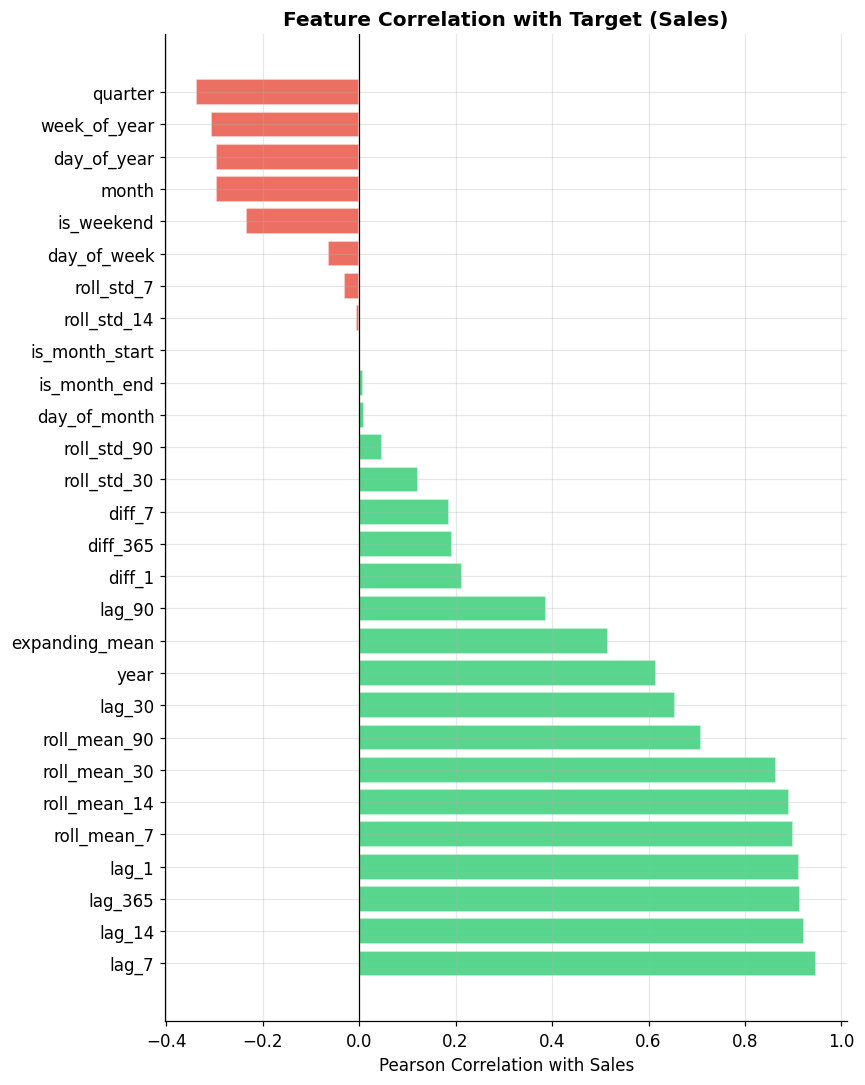


 Top 5 positively correlated features:
lag_7          0.947993
lag_14         0.922630
lag_365        0.913933
lag_1          0.911345
roll_mean_7    0.899040
Name: sales, dtype: float64

 Top 5 negatively correlated features:
is_weekend     -0.235353
month          -0.296269
day_of_year    -0.296958
week_of_year   -0.307750
quarter        -0.338173
Name: sales, dtype: float64


In [31]:
# Feature Correlation with Target 
correlations = df_feat.corr()['sales'].drop('sales').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in correlations]
ax.barh(correlations.index, correlations.values, color=colors, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Sales')
ax.set_title('Feature Correlation with Target (Sales)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Top 5 positively correlated features:')
print(correlations.head())
print('\n Top 5 negatively correlated features:')
print(correlations.tail())

---
## Section 8: Machine Learning for Forecasting

With the engineered features from Section 7, we can apply standard ML regressors.

### Models
| Model | Strengths |
|---|---|
| **Linear Regression** | Fast, interpretable baseline |
| **Random Forest** | Non-linear, handles feature interactions |
| **XGBoost / Gradient Boosting** | State-of-the-art for tabular time series |

> ⚠️ **Important:** Use **time-based train/test split**, never random shuffling, to avoid data leakage.

In [32]:
# Section 8 — ML Forecasting with Random Forest & XGBoost

!pip install xgboost --quiet

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

#Prepare features / target
feature_cols = [c for c in df_feat.columns if c != 'sales']
X_all = df_feat[feature_cols]
y_all = df_feat['sales']

# Time-based split (last 20% = test)
split_idx  = int(len(df_feat) * 0.8)
X_tr, X_te = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_tr, y_te = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

print(f'Train: {X_tr.shape} | Test: {X_te.shape}')

# Train models 
ml_models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest':    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':          xgb.XGBRegressor(n_estimators=300, learning_rate=0.05,
                                          max_depth=5, random_state=42, verbosity=0)
}

# Scale features for Ridge
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

ml_results = {}
for name, model in ml_models.items():
    if 'Ridge' in name:
        model.fit(X_tr_sc, y_tr)
        preds = model.predict(X_te_sc)
    else:
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)

    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mape = np.mean(np.abs((y_te.values - preds) / y_te.values)) * 100

    ml_results[name] = {'preds': preds, 'mae': mae, 'rmse': rmse, 'mape': mape, 'model': model}
    print(f'  {name}: MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%')

Train: (1168, 28) | Test: (293, 28)
  Ridge Regression: MAE=0.03  RMSE=0.04  MAPE=0.02%
  Random Forest: MAE=2.84  RMSE=5.12  MAPE=1.48%
  XGBoost: MAE=2.66  RMSE=4.72  MAPE=1.39%


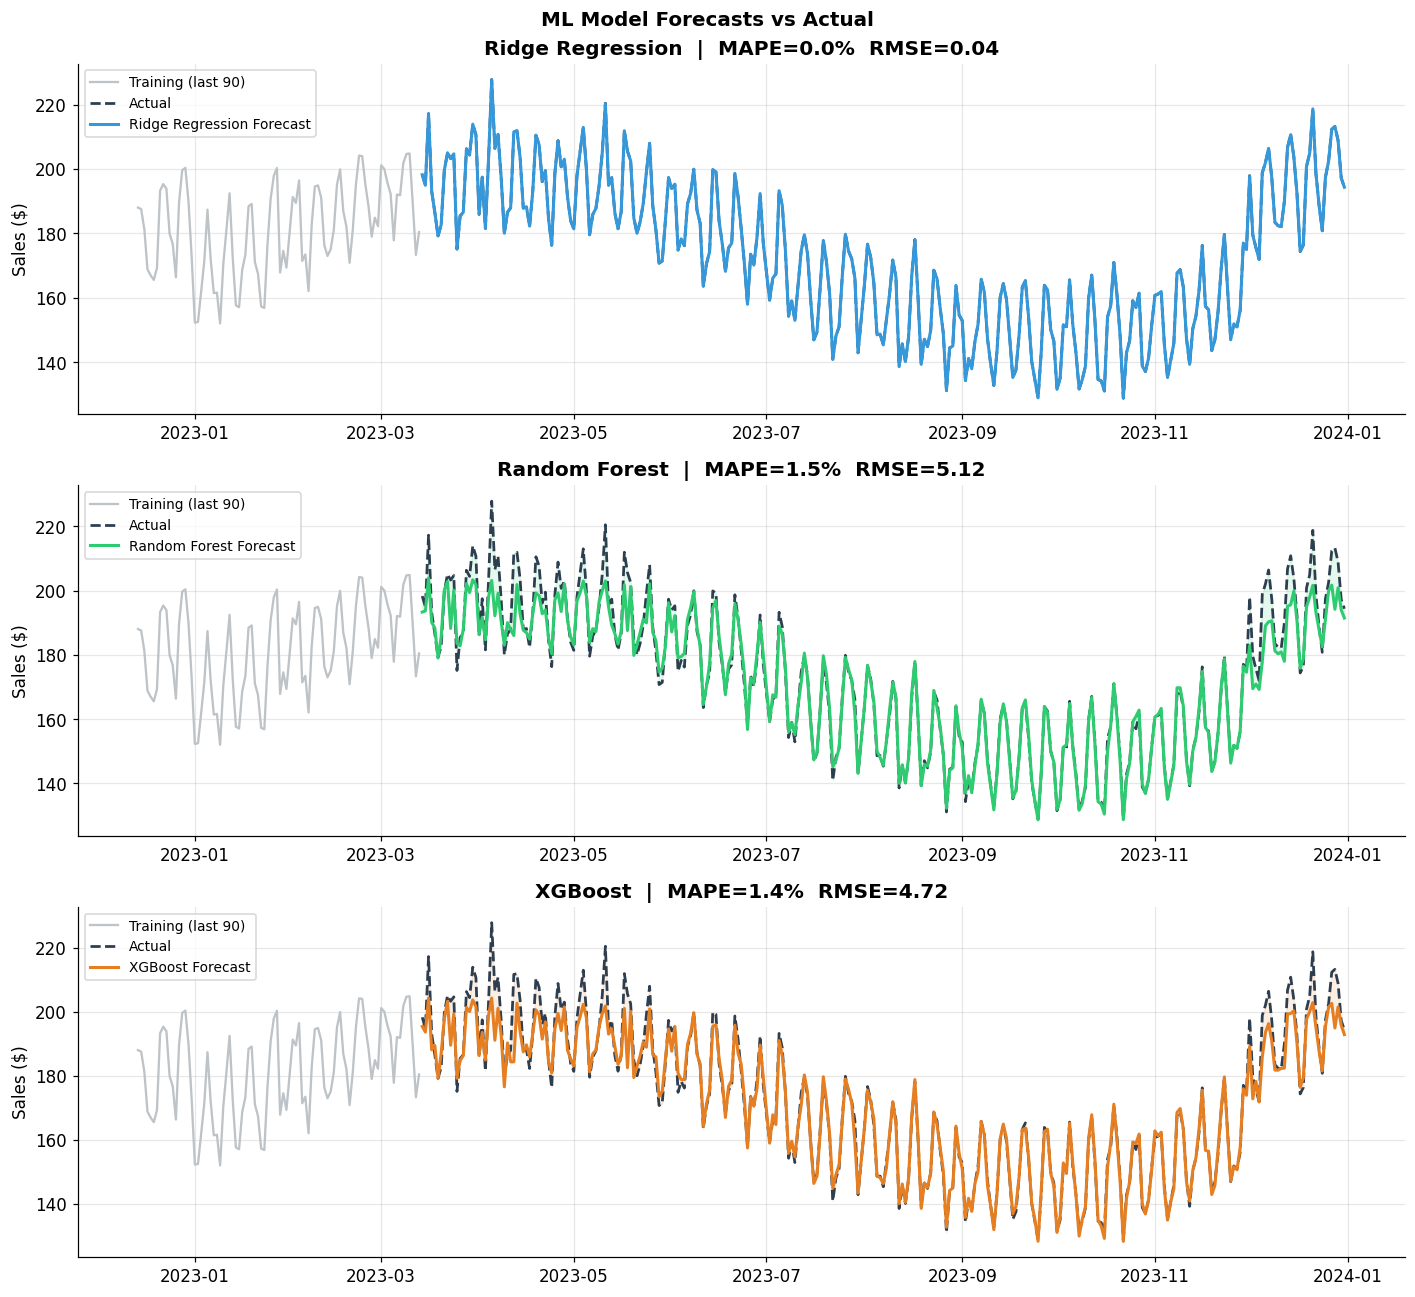

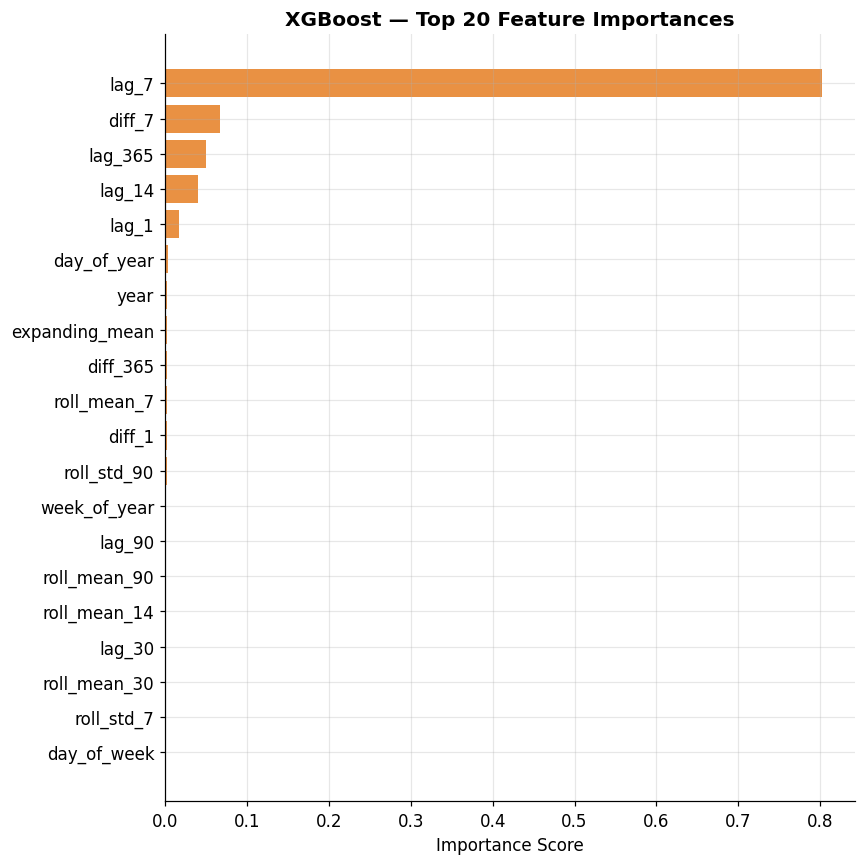

In [33]:
# Visual: Forecasts + Feature Importance 
fig, axes = plt.subplots(len(ml_models), 1, figsize=(13, 12))
colors_ml = ['#3498db', '#2ecc71', '#e67e22']

for ax, (name, res), color in zip(axes, ml_results.items(), colors_ml):
    ax.plot(y_tr.index[-90:], y_tr.values[-90:], color='#bdc3c7', linewidth=1.5, label='Training (last 90)')
    ax.plot(y_te.index, y_te.values,             color='#2c3e50', linewidth=1.8, linestyle='--', label='Actual')
    ax.plot(y_te.index, res['preds'],             color=color, linewidth=2, label=f'{name} Forecast')
    ax.fill_between(y_te.index, y_te.values, res['preds'], alpha=0.12, color=color)
    ax.set_title(f'{name}  |  MAPE={res["mape"]:.1f}%  RMSE={res["rmse"]:.2f}', fontweight='bold')
    ax.set_ylabel('Sales ($)')
    ax.legend(fontsize=9)

plt.suptitle('ML Model Forecasts vs Actual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature importance from XGBoost
xgb_model  = ml_results['XGBoost']['model']
importance  = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
top20 = importance.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color='#e67e22', alpha=0.85)
ax.set_title('XGBoost — Top 20 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## Section 9: LSTM Deep Learning Forecasting

**Long Short-Term Memory (LSTM)** networks are a type of Recurrent Neural Network designed to learn **long-range temporal dependencies**.

### LSTM Cell Gates
```
Forget Gate  → decides what to discard from cell state
Input Gate   → decides what new information to store
Output Gate  → decides what to output as hidden state
```

### Sequence-to-One Forecasting
We use a **sliding window** approach:
- Input: last `window_size` time steps → `[x_t-w, ..., x_t-1]`
- Target: next value → `x_t`

In [34]:
# Section 9 — LSTM Forecasting with PyTorch

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# Prepare data
sales_values = df['sales'].values.reshape(-1, 1)

# Normalise to [0,1] — crucial for LSTM stability
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
scaled      = scaler_lstm.fit_transform(sales_values)

WINDOW   = 30      # look-back window (days)
HORIZON  = 1       # forecast horizon (days)
TEST_DAYS = 180    # ~6 months of daily test data

def create_sequences(data, window, horizon=1):
    """Convert a flat series into (X, y) sequence pairs."""
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i : i + window])
        y.append(data[i + window : i + window + horizon])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled, WINDOW, HORIZON)

# Time-based split
split_lstm = len(X_seq) - TEST_DAYS
X_tr_l, X_te_l = X_seq[:split_lstm], X_seq[split_lstm:]
y_tr_l, y_te_l = y_seq[:split_lstm], y_seq[split_lstm:]

# Convert to tensors
X_tr_t = torch.tensor(X_tr_l, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr_l, dtype=torch.float32).squeeze(-1)
X_te_t = torch.tensor(X_te_l, dtype=torch.float32)
y_te_t = torch.tensor(y_te_l, dtype=torch.float32).squeeze(-1)

print(f'Train sequences: {X_tr_t.shape} | Test sequences: {X_te_t.shape}')

Train sequences: torch.Size([1616, 30, 1]) | Test sequences: torch.Size([180, 30, 1])


In [35]:
#  LSTM Model Architecture 
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2,
                 output_size=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)          # (batch, seq, hidden)
        last_step   = lstm_out[:, -1, :]    # take last time step
        return self.fc(last_step).squeeze(-1)

lstm_model = LSTMForecaster(input_size=1, hidden_size=64, num_layers=2)
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion  = nn.MSELoss()
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

total_params = sum(p.numel() for p in lstm_model.parameters())
print(f' LSTM Forecaster | Parameters: {total_params:,}')
print(lstm_model)

 LSTM Forecaster | Parameters: 52,545
LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [36]:
# Training Loop 
dataset_lstm = torch.utils.data.TensorDataset(X_tr_t, y_tr_t)
loader_lstm  = DataLoader(dataset_lstm, batch_size=64, shuffle=False)

EPOCHS      = 40
train_losses = []

lstm_model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for X_batch, y_batch in loader_lstm:
        optimizer.zero_grad()
        preds = lstm_model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)   # gradient clipping
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(loader_lstm)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1:02d}/{EPOCHS}  Loss: {avg_loss:.6f}')

# Evaluate on test set 
lstm_model.eval()
with torch.no_grad():
    lstm_preds_scaled = lstm_model(X_te_t).numpy().reshape(-1, 1)

# Inverse transform back to original scale
lstm_preds = scaler_lstm.inverse_transform(lstm_preds_scaled).flatten()
y_actual   = scaler_lstm.inverse_transform(y_te_l.reshape(-1, 1)).flatten()

mae_lstm  = mean_absolute_error(y_actual, lstm_preds)
rmse_lstm = np.sqrt(mean_squared_error(y_actual, lstm_preds))
mape_lstm = np.mean(np.abs((y_actual - lstm_preds) / y_actual)) * 100

print(f'\n📊 LSTM Performance:')
print(f'   MAE  = {mae_lstm:.2f}')
print(f'   RMSE = {rmse_lstm:.2f}')
print(f'   MAPE = {mape_lstm:.2f}%')

  Epoch 10/40  Loss: 0.042237
  Epoch 20/40  Loss: 0.014428
  Epoch 30/40  Loss: 0.013341
  Epoch 40/40  Loss: 0.013844

📊 LSTM Performance:
   MAE  = 11.85
   RMSE = 14.11
   MAPE = 7.28%


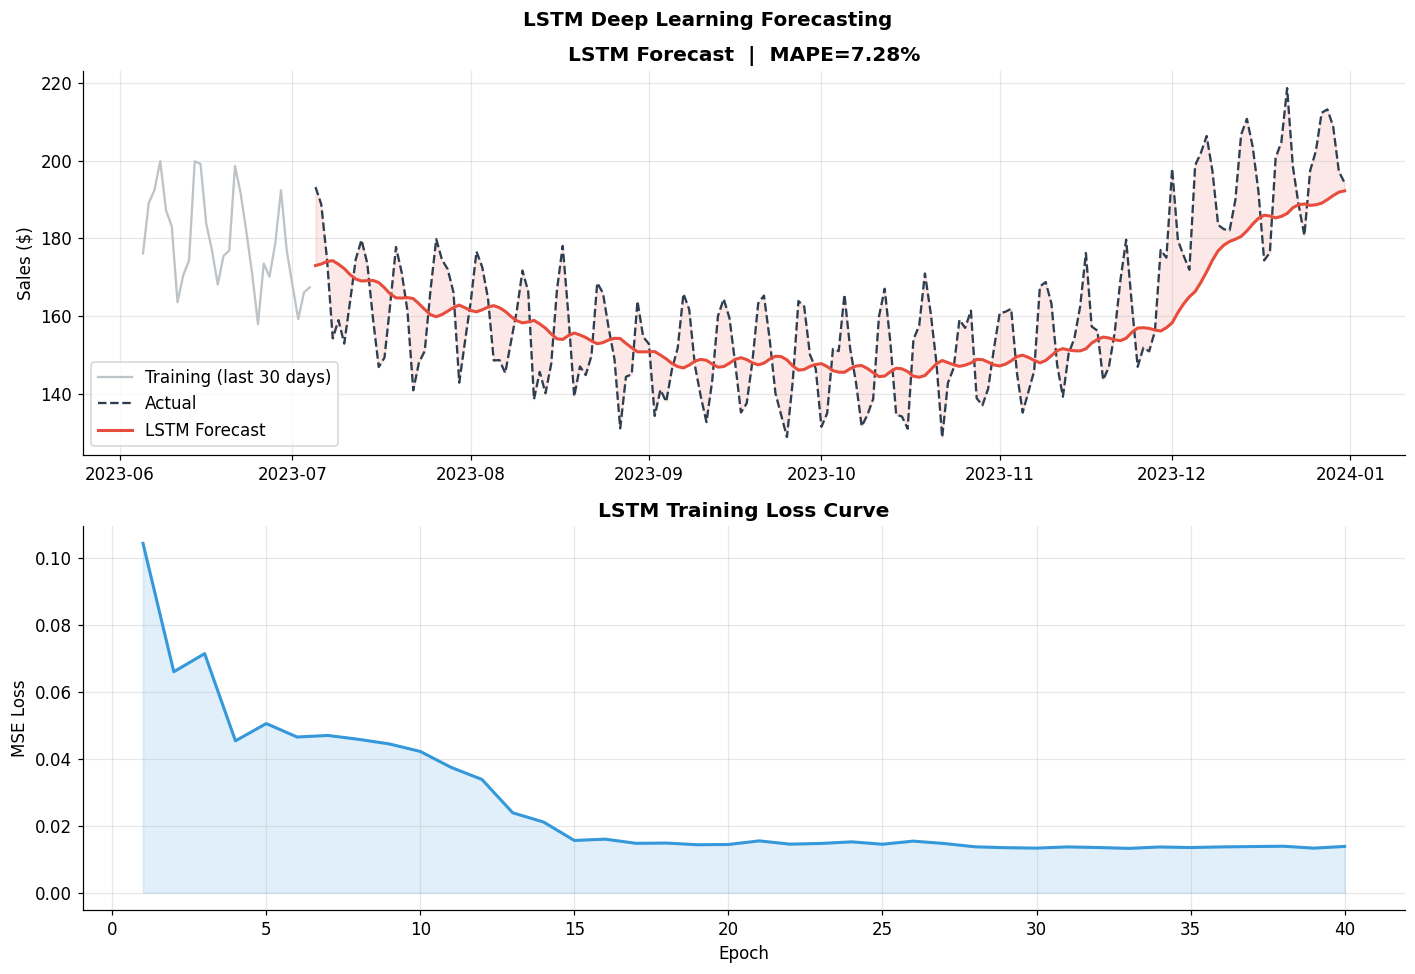

In [37]:
#Visualise LSTM Results 
test_dates = df.index[-(TEST_DAYS):]
test_dates = test_dates[:len(lstm_preds)]   # align length

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Forecast
axes[0].plot(df.index[-TEST_DAYS-30:-TEST_DAYS], df['sales'].values[-TEST_DAYS-30:-TEST_DAYS],
             color='#bdc3c7', linewidth=1.5, label='Training (last 30 days)')
axes[0].plot(test_dates, y_actual[:len(test_dates)],
             color='#2c3e50', linewidth=1.5, linestyle='--', label='Actual')
axes[0].plot(test_dates, lstm_preds[:len(test_dates)],
             color='#e74c3c', linewidth=2, label='LSTM Forecast')
axes[0].fill_between(test_dates, y_actual[:len(test_dates)], lstm_preds[:len(test_dates)],
                      alpha=0.12, color='#e74c3c')
axes[0].set_title(f'LSTM Forecast  |  MAPE={mape_lstm:.2f}%', fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].legend()

# Training loss curve
axes[1].plot(range(1, EPOCHS+1), train_losses, color='#3498db', linewidth=2)
axes[1].fill_between(range(1, EPOCHS+1), train_losses, alpha=0.15, color='#3498db')
axes[1].set_title('LSTM Training Loss Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')

plt.suptitle('LSTM Deep Learning Forecasting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 10: Facebook Prophet

**Prophet** is an open-source forecasting library from Meta, designed for **business time series** with:
- Strong seasonal effects (daily, weekly, yearly)
- Holiday effects
- Missing data
- Trend changepoints

### Prophet's Additive Model
```
y(t) = trend(t) + seasonality(t) + holidays(t) + noise
```

### Prophet API
Prophet uses a simple, intuitive DataFrame API:
```python
df_prophet = pd.DataFrame({'ds': dates, 'y': values})
model = Prophet()
model.fit(df_prophet)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)
```

In [38]:

# Section 10 — Facebook Prophet Forecasting

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import logging
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# Prophet expects columns: 'ds' (datetime) and 'y' (values)
prophet_df = df.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})

# Use monthly data for speed (Prophet works great on monthly too)
prophet_monthly = df_monthly.reset_index().rename(
    columns={'date': 'ds', 'sales': 'y'}
)[['ds', 'y']]

# Train/test split (last 12 months = test)
prophet_train = prophet_monthly.iloc[:-12]
prophet_test  = prophet_monthly.iloc[-12:]


prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # monthly data — no weekly
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,   # flexibility of trend changepoints
    interval_width=0.90             # 90% uncertainty intervals
)

# Add custom monthly seasonality
prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

prophet_model.fit(prophet_train)


# ── Forecast ──────────────────────────────────────────────────
future   = prophet_model.make_future_dataframe(periods=12, freq='ME')
forecast = prophet_model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12).to_string(index=False))

14:08:55 - cmdstanpy - INFO - Chain [1] start processing
14:08:55 - cmdstanpy - INFO - Chain [1] done processing


        ds       yhat  yhat_lower  yhat_upper
2023-01-31 168.023363  165.833640  170.465355
2023-02-28 182.725932  180.519804  185.064923
2023-03-31 192.628106  190.256758  194.897856
2023-04-30 193.346135  191.153396  195.624131
2023-05-31 188.445814  186.162495  190.719300
2023-06-30 175.101762  172.850019  177.249772
2023-07-31 160.544062  158.308128  162.670368
2023-08-31 150.529661  148.228782  152.765638
2023-09-30 141.476282  139.102990  143.846507
2023-10-31 145.441628  143.082716  147.703801
2023-11-30 151.835279  149.513997  153.986970
2023-12-31 192.953304  190.731507  195.266801


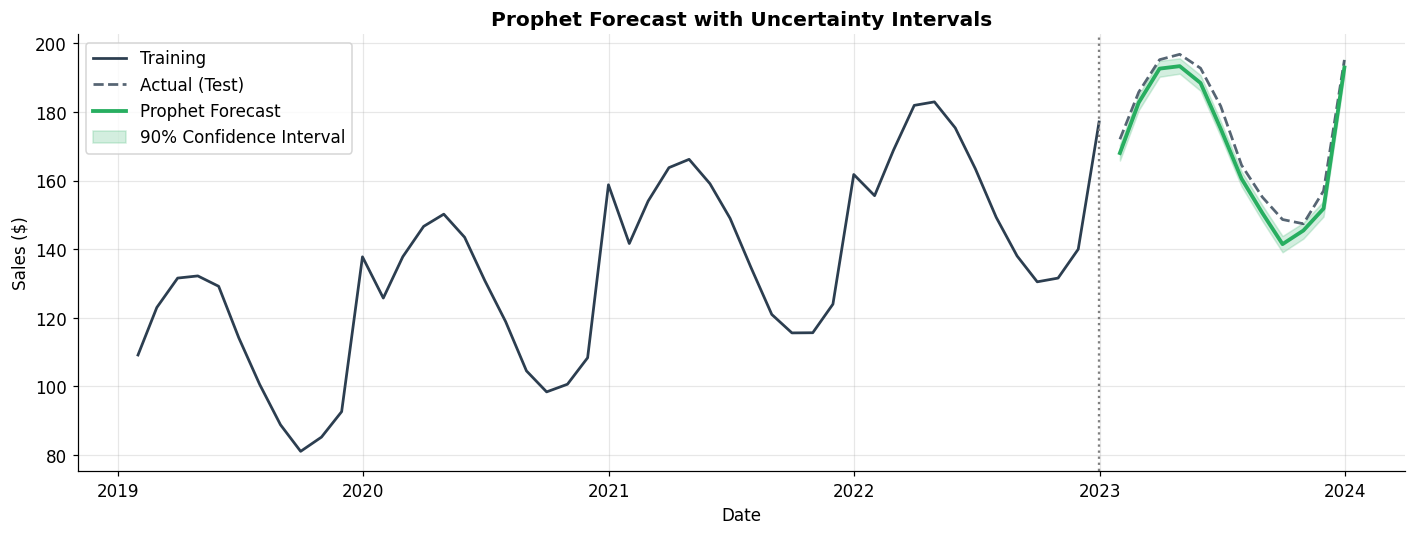

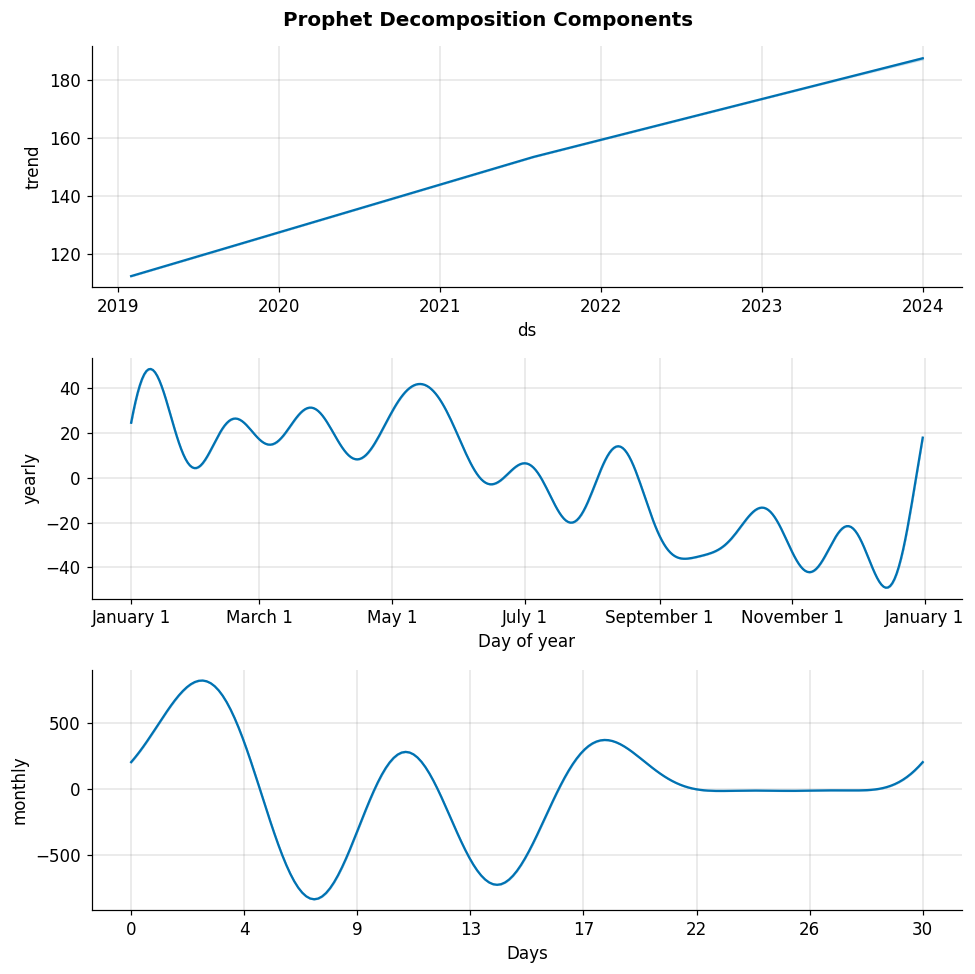


 Prophet Performance:
   MAPE = 2.41%
   RMSE = 4.38


In [39]:
from prophet.plot import plot_plotly, plot_components_plotly

fig, ax = plt.subplots(figsize=(13, 5))

# Training data
ax.plot(prophet_train['ds'], prophet_train['y'],
        color='#2c3e50', linewidth=1.8, label='Training')

# Test actual
ax.plot(prophet_test['ds'], prophet_test['y'],
        color='#2c3e50', linestyle='--', linewidth=1.8, label='Actual (Test)', alpha=0.8)

# Forecast
forecast_tail = forecast.tail(12)
ax.plot(forecast_tail['ds'], forecast_tail['yhat'],
        color='#27ae60', linewidth=2.5, label='Prophet Forecast')

# Uncertainty interval
ax.fill_between(
    forecast_tail['ds'],
    forecast_tail['yhat_lower'],
    forecast_tail['yhat_upper'],
    alpha=0.2, color='#27ae60', label='90% Confidence Interval'
)

ax.axvline(prophet_train['ds'].iloc[-1], color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Prophet Forecast with Uncertainty Intervals', fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

fig2 = prophet_model.plot_components(forecast)
fig2.suptitle('Prophet Decomposition Components', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Metrics
test_preds = forecast.set_index('ds')['yhat'].reindex(prophet_test['ds'].values).values
test_actuals = prophet_test['y'].values
mape_p  = np.mean(np.abs((test_actuals - test_preds) / test_actuals)) * 100
rmse_p  = np.sqrt(mean_squared_error(test_actuals, test_preds))
print(f'\n Prophet Performance:')
print(f'   MAPE = {mape_p:.2f}%')
print(f'   RMSE = {rmse_p:.2f}')

---
## Section 11: Model Evaluation & Comparison

### Forecasting Metrics
| Metric | Formula | Notes |
|---|---|---|
| **MAE** | mean\|actual − predicted\| | Easy to interpret; same units as target |
| **RMSE** | √mean(actual−predicted)² | Penalises large errors more heavily |
| **MAPE** | mean(\|actual−predicted\|/actual)×100 | Scale-independent percentage |
| **SMAPE** | mean(2\|A−F\|/(\|A\|+\|F\|))×100 | Symmetric MAPE — handles near-zero values |
| **R²** | 1 − SS_res/SS_tot | Proportion of variance explained |

> 💡 **No single metric is perfect.** Always report multiple metrics and look at residual plots.

In [40]:
# Section 11 — Model Comparison Dashboard

from sklearn.metrics import r2_score

def compute_metrics(actual, predicted, model_name):
    """Compute all forecasting metrics."""
    actual, predicted = np.array(actual), np.array(predicted)
    mae   = mean_absolute_error(actual, predicted)
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mape  = np.mean(np.abs((actual - predicted) / actual)) * 100
    smape = np.mean(2 * np.abs(actual - predicted) / (np.abs(actual) + np.abs(predicted))) * 100
    r2    = r2_score(actual, predicted)
    return {'Model': model_name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'MAPE(%)': round(mape, 2), 'SMAPE(%)': round(smape, 2), 'R²': round(r2, 4)}

# ── Use the monthly test set for a fair comparison ────────────
# All models are compared on df_monthly test split (last 12 months)
# We already have: hw_forecast, sarima_pred, lstm (daily — re-run on monthly for fairness)
# We'll use the results already computed above

comparison_rows = [
    compute_metrics(test_hw.values, hw_forecast.values,   'Holt-Winters'),
    compute_metrics(test_arima.values, sarima_pred.values, 'SARIMA'),
    compute_metrics(test_actuals, test_preds,              'Prophet'),
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.set_index('Model', inplace=True)

print(' Model Comparison (Monthly Sales, Last 12 Months):')
print('=' * 65)
print(comparison_df.to_string())

best_mape_model = comparison_df['MAPE(%)'].idxmin()
print(f'\n Best MAPE: {best_mape_model} ({comparison_df.loc[best_mape_model, "MAPE(%)"]:.2f}%)')

 Model Comparison (Monthly Sales, Last 12 Months):
               MAE  RMSE  MAPE(%)  SMAPE(%)      R²
Model                                              
Holt-Winters  1.42  1.82     0.83      0.84  0.9902
SARIMA        2.53  3.72     1.39      1.41  0.9590
Prophet       4.09  4.38     2.41      2.44  0.9432

 Best MAPE: Holt-Winters (0.83%)


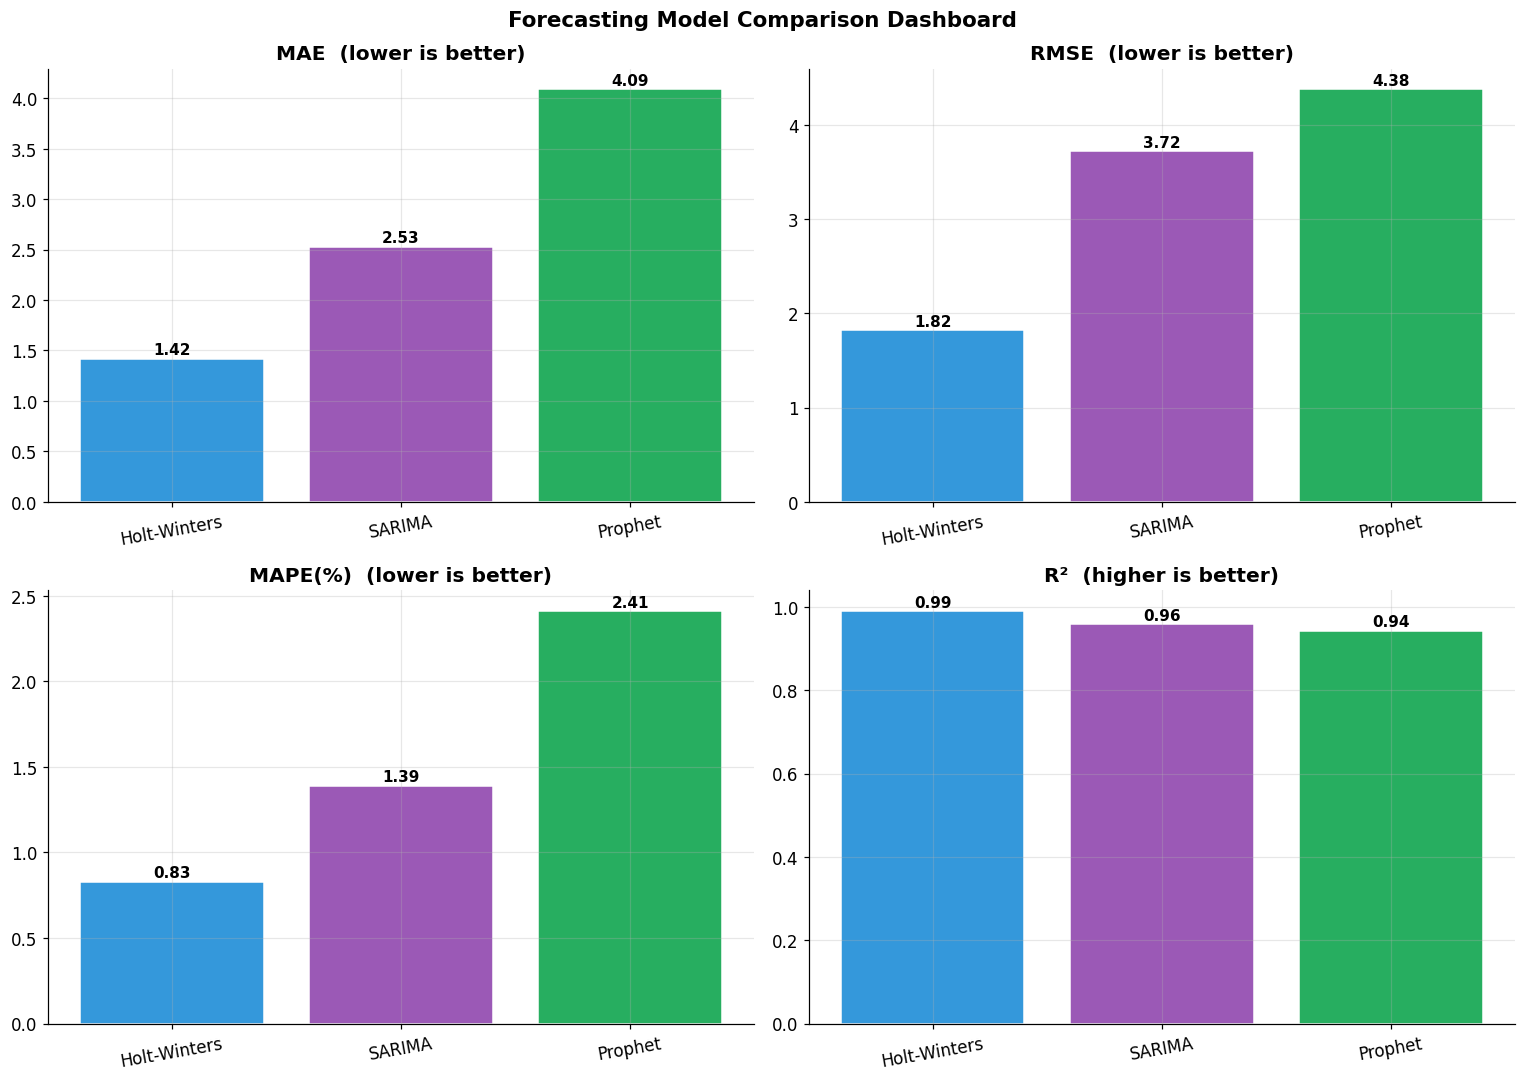

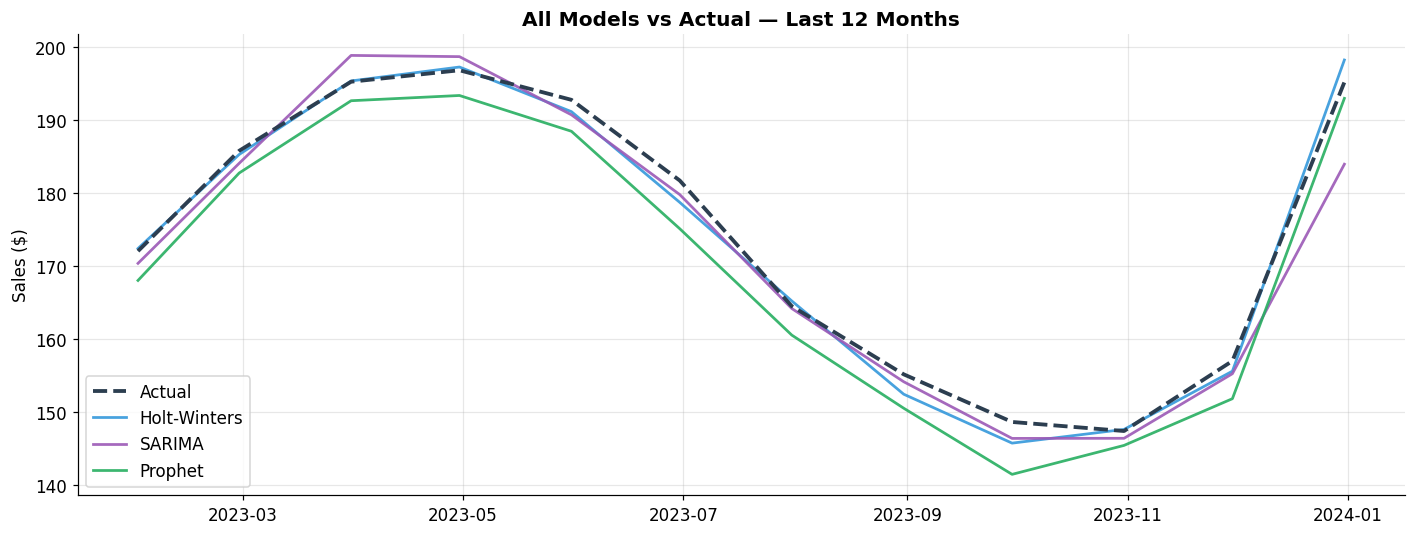

In [41]:
# Comparison Dashboard 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = ['MAE', 'RMSE', 'MAPE(%)', 'R²']
bar_colors = ['#3498db', '#9b59b6', '#27ae60']

for ax, metric in zip(axes.flat, metrics_to_plot):
    values = comparison_df[metric]
    bars   = ax.bar(values.index, values.values, color=bar_colors, edgecolor='white')
    for bar, val in zip(bars, values.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'{metric}  ({'lower is better' if metric != 'R²' else 'higher is better'})',
                 fontweight='bold')
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Forecasting Model Comparison Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_hw.index,    test_hw.values,         color='#2c3e50', linewidth=2.5, linestyle='--', label='Actual', zorder=5)
ax.plot(test_hw.index,    hw_forecast.values,     color='#3498db', linewidth=1.8, label='Holt-Winters', alpha=0.9)
ax.plot(test_arima.index, sarima_pred.values,     color='#9b59b6', linewidth=1.8, label='SARIMA', alpha=0.9)
ax.plot(prophet_test['ds'].values, test_preds,    color='#27ae60', linewidth=1.8, label='Prophet', alpha=0.9)
ax.set_title('All Models vs Actual — Last 12 Months', fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 12: 🚀 Mini Project / End-to-End Forecasting Pipeline

### Objective
Build a **production-ready forecasting pipeline** that:
1. Loads and validates raw time series data
2. Detects anomalies and handles missing values
3. Decomposes and analyses the series
4. Trains multiple models
5. Selects the best model automatically
6. Generates a **future forecast with confidence intervals**
7. Produces a final **forecast report**

### Scenario
You are a data scientist at an e-commerce company. You need to forecast **daily website traffic** for the next 30 days to plan server capacity.

In [42]:

# Section 12 — Mini Project: Website Traffic Forecasting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

#Step 1: Generate realistic website traffic data 
np.random.seed(99)
dates = pd.date_range(start='2022-01-01', end='2024-06-30', freq='D')
n     = len(dates)

# Base traffic with growth
trend       = np.linspace(8000, 14000, n)
# Strong weekly seasonality (less traffic weekends)
weekly      = -1500 * (pd.DatetimeIndex(dates).dayofweek >= 5).astype(float)
# Yearly cycle (lower in summer, higher in Q4)
yearly      = 1200 * np.sin(2 * np.pi * np.arange(n) / 365.25 + np.pi)
# Random spikes (marketing campaigns)
spikes      = np.zeros(n)
spike_idx   = np.random.choice(n, 15, replace=False)
spikes[spike_idx] = np.random.uniform(2000, 5000, 15)
# Add some anomalies (server outages)
outage_idx  = np.random.choice(n, 5, replace=False)
spikes[outage_idx] = -np.random.uniform(3000, 6000, 5)
# Noise
noise       = np.random.normal(0, 350, n)

traffic = trend + weekly + yearly + spikes + noise
traffic = np.clip(traffic, 500, None)   # minimum 500 visits/day

df_traffic = pd.DataFrame({'date': dates, 'traffic': traffic.round(0).astype(int)})
df_traffic.set_index('date', inplace=True)

print(f' Website Traffic Dataset: {len(df_traffic)} days')
print(df_traffic['traffic'].describe().round(0))

 Website Traffic Dataset: 912 days
count      912.0
mean     10448.0
std       2157.0
min       3873.0
25%       8924.0
50%      10560.0
75%      12161.0
max      17734.0
Name: traffic, dtype: float64


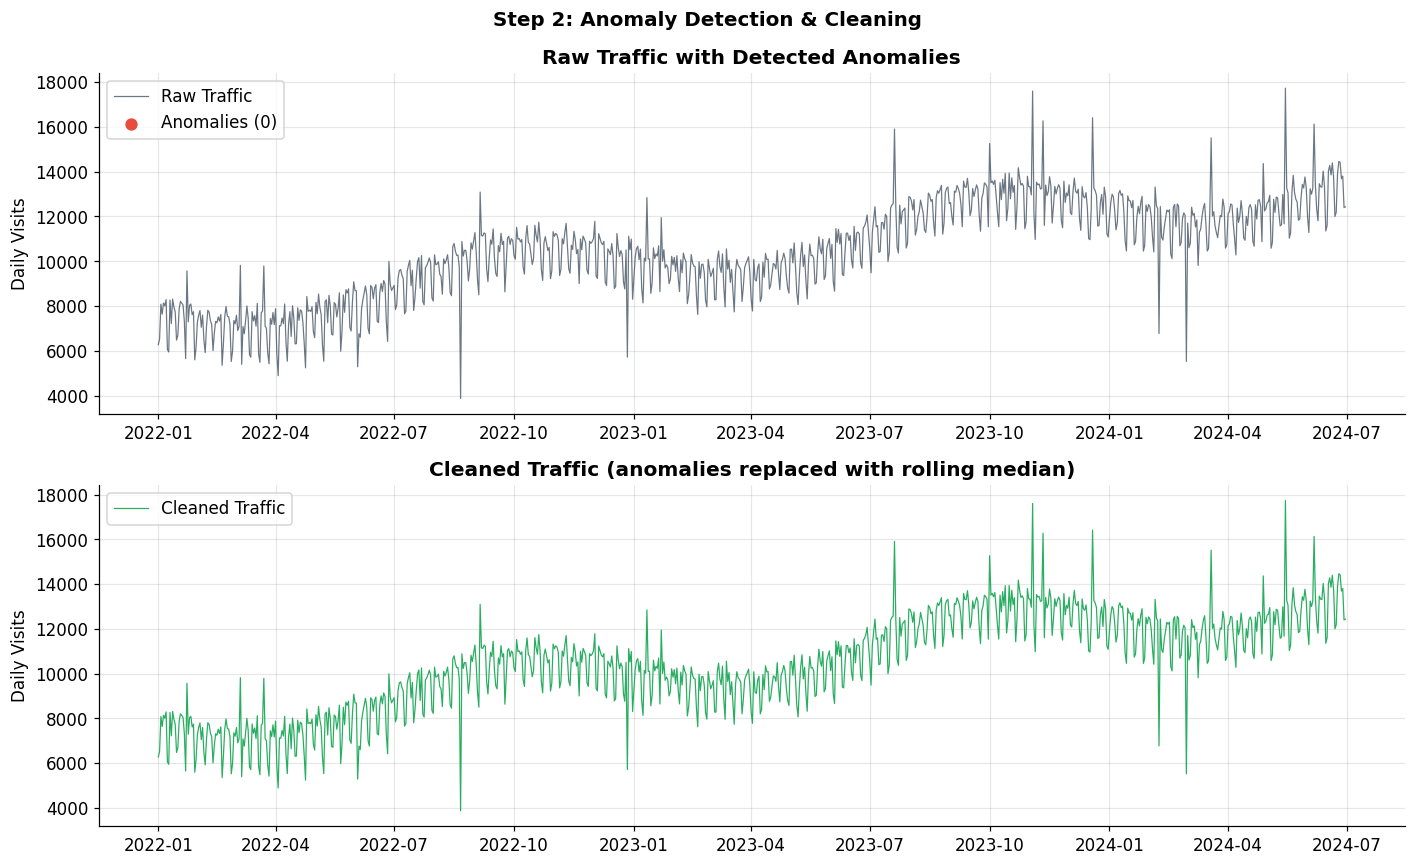

 Found and cleaned 0 anomalies (0.0% of data)


In [43]:
def detect_anomalies_iqr(series, multiplier=2.5):
    """Flag anomalies using IQR method."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return (series < lower) | (series > upper)

anomalies    = detect_anomalies_iqr(df_traffic['traffic'])
n_anomalies  = anomalies.sum()

# ── Handle anomalies: replace with rolling median ─────────────
df_clean = df_traffic.copy()
df_clean.loc[anomalies, 'traffic'] = df_clean['traffic'].rolling(
    window=7, center=True, min_periods=1
).median()[anomalies]

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(df_traffic.index, df_traffic['traffic'],
             color='#2c3e50', linewidth=0.8, label='Raw Traffic', alpha=0.7)
axes[0].scatter(df_traffic.index[anomalies], df_traffic['traffic'][anomalies],
                color='#e74c3c', s=50, zorder=5, label=f'Anomalies ({n_anomalies})')
axes[0].set_title('Raw Traffic with Detected Anomalies', fontweight='bold')
axes[0].set_ylabel('Daily Visits')
axes[0].legend()

axes[1].plot(df_clean.index, df_clean['traffic'],
             color='#27ae60', linewidth=0.8, label='Cleaned Traffic')
axes[1].set_title('Cleaned Traffic (anomalies replaced with rolling median)', fontweight='bold')
axes[1].set_ylabel('Daily Visits')
axes[1].legend()

plt.suptitle('Step 2: Anomaly Detection & Cleaning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f' Found and cleaned {n_anomalies} anomalies ({n_anomalies/len(df_traffic)*100:.1f}% of data)')

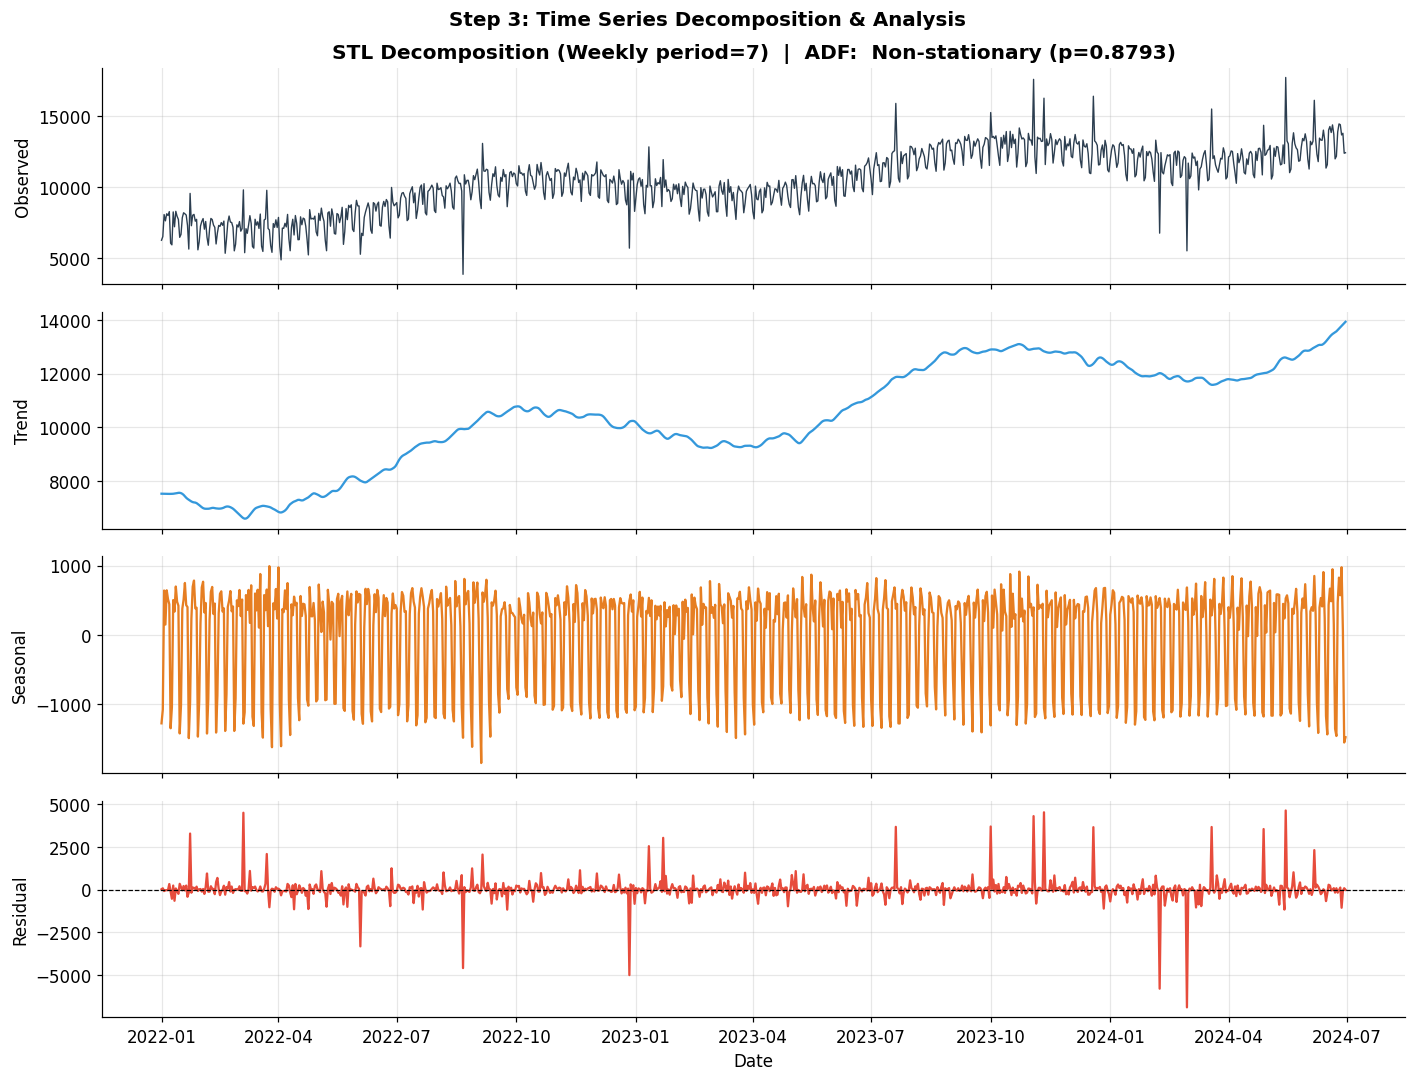

In [44]:
# Step 3: Analysis — STL Decomposition + Stationarity 
stl_traffic = STL(df_clean['traffic'], period=7, robust=True).fit()

# ADF test
adf_stat, adf_p, *_ = adfuller(df_clean['traffic'])
stationary_status = ' Stationary' if adf_p < 0.05 else ' Non-stationary'

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
stl_data = [
    (stl_traffic.observed,  'Observed',  '#2c3e50'),
    (stl_traffic.trend,     'Trend',     '#3498db'),
    (stl_traffic.seasonal,  'Seasonal',  '#e67e22'),
    (stl_traffic.resid,     'Residual',  '#e74c3c'),
]
for ax, (data, label, color) in zip(axes, stl_data):
    ax.plot(data.index, data, color=color, linewidth=0.9 if label=='Observed' else 1.5)
    ax.set_ylabel(label)
    if label == 'Residual': ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

axes[0].set_title(f'STL Decomposition (Weekly period=7)  |  ADF: {stationary_status} (p={adf_p:.4f})',
                   fontweight='bold')
axes[-1].set_xlabel('Date')
plt.suptitle('Step 3: Time Series Decomposition & Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [45]:
# step 4: Train Multiple Models & Select Best
from statsmodels.tsa.holtwinters import ExponentialSmoothing

FORECAST_HORIZON = 30   # 30 days ahead
TEST_N           = 60   # hold out last 60 days

train_ts  = df_clean['traffic'][:-TEST_N]
test_ts   = df_clean['traffic'][-TEST_N:]

#  Model 1: Holt-Winters
hw_traffic = ExponentialSmoothing(
    train_ts, trend='add', seasonal='add', seasonal_periods=7
).fit(optimized=True)
hw_pred = hw_traffic.forecast(TEST_N)

#  Model 2: Prophet
df_p = df_clean.reset_index().rename(columns={'date': 'ds', 'traffic': 'y'})
df_p_train = df_p.iloc[:-TEST_N]
df_p_test  = df_p.iloc[-TEST_N:]

prop = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,
    interval_width=0.90
)
prop.fit(df_p_train)
future_p    = prop.make_future_dataframe(periods=TEST_N + FORECAST_HORIZON, freq='D')
forecast_p  = prop.predict(future_p)
prophet_test_pred   = forecast_p['yhat'].values[-TEST_N - FORECAST_HORIZON:-FORECAST_HORIZON]
prophet_future_pred = forecast_p['yhat'].values[-FORECAST_HORIZON:]
prophet_future_lo   = forecast_p['yhat_lower'].values[-FORECAST_HORIZON:]
prophet_future_hi   = forecast_p['yhat_upper'].values[-FORECAST_HORIZON:]

#  model 3: XGBoost (re-use feature engineering)
df_feat_tr = create_time_features(df_clean, target_col='traffic')
df_feat_tr.dropna(inplace=True)
feat_cols = [c for c in df_feat_tr.columns if c != 'traffic']
Xf = df_feat_tr[feat_cols]
yf = df_feat_tr['traffic']
split_f   = len(Xf) - TEST_N
Xf_tr, Xf_te = Xf.iloc[:split_f], Xf.iloc[split_f:]
yf_tr, yf_te = yf.iloc[:split_f], yf.iloc[split_f:]

xgb_traffic = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                                 random_state=42, verbosity=0)
xgb_traffic.fit(Xf_tr, yf_tr)
xgb_pred_test = xgb_traffic.predict(Xf_te)


results_mini = pd.DataFrame([
    compute_metrics(test_ts.values, hw_pred.values,           'Holt-Winters'),
    compute_metrics(test_ts.values, prophet_test_pred,        'Prophet'),
    compute_metrics(yf_te.values,   xgb_pred_test,            'XGBoost'),
]).set_index('Model')

print(' Mini Project — Model Comparison (60-day test):')
print(results_mini.to_string())

best_model_name = results_mini['MAPE(%)'].idxmin()
print(f'\n Auto-selected Best Model: {best_model_name}')

14:08:58 - cmdstanpy - INFO - Chain [1] start processing
14:08:59 - cmdstanpy - INFO - Chain [1] done processing


 Mini Project — Model Comparison (60-day test):
                 MAE    RMSE  MAPE(%)  SMAPE(%)      R²
Model                                                  
Holt-Winters  459.17  855.02     3.36      3.45  0.5002
Prophet       486.45  878.84     3.52      3.66  0.4719
XGBoost       232.66  356.63     1.71      1.74  0.9130

 Auto-selected Best Model: XGBoost


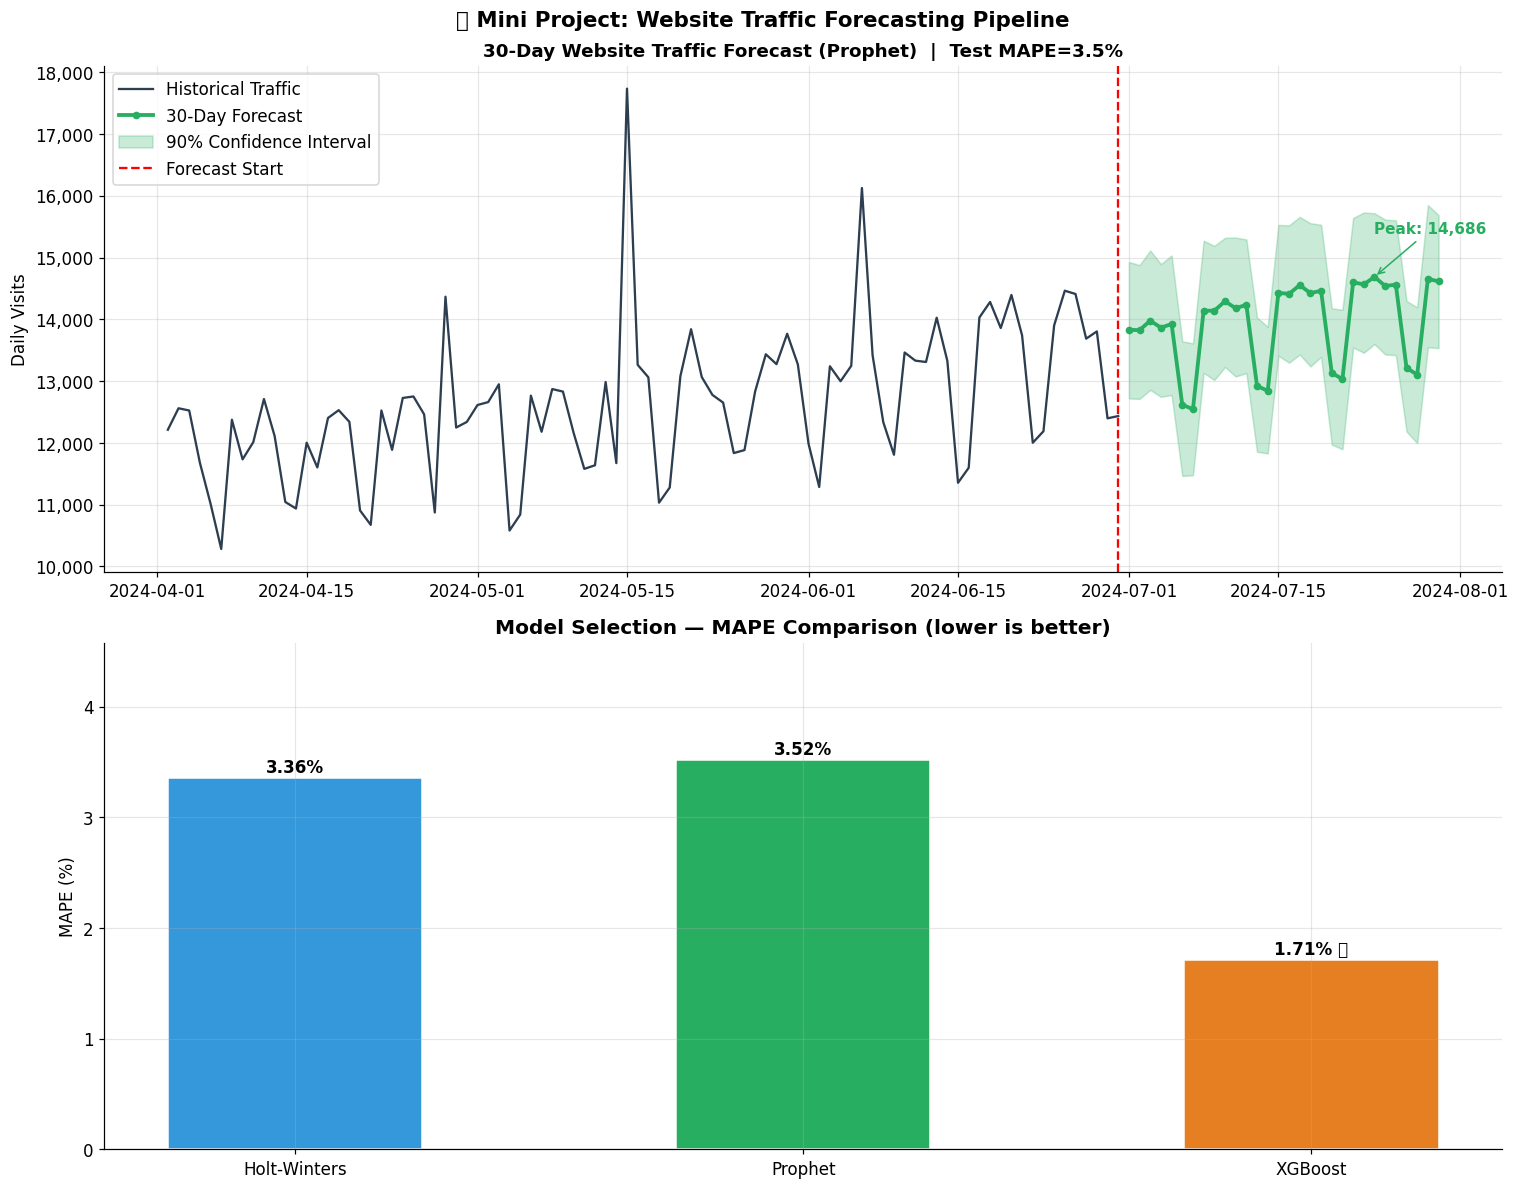

In [46]:
future_dates = pd.date_range(
    start=df_clean.index[-1] + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON, freq='D'
)

# Use Prophet for final forecast (includes uncertainty intervals)
fig, axes = plt.subplots(2, 1, figsize=(14, 11))


# Show last 90 days of history + 30-day forecast
hist_window = 90
axes[0].plot(df_clean.index[-hist_window:],
             df_clean['traffic'].values[-hist_window:],
             color='#2c3e50', linewidth=1.5, label='Historical Traffic')

axes[0].plot(future_dates, prophet_future_pred,
             color='#27ae60', linewidth=2.5, label='30-Day Forecast', marker='o', markersize=4)

axes[0].fill_between(future_dates, prophet_future_lo, prophet_future_hi,
                      alpha=0.25, color='#27ae60', label='90% Confidence Interval')

axes[0].axvline(df_clean.index[-1], color='red', linestyle='--',
                linewidth=1.5, label='Forecast Start')

# Annotate peak forecast day
peak_idx  = np.argmax(prophet_future_pred)
axes[0].annotate(
    f'Peak: {int(prophet_future_pred[peak_idx]):,}',
    xy=(future_dates[peak_idx], prophet_future_pred[peak_idx]),
    xytext=(future_dates[peak_idx], prophet_future_pred[peak_idx] + 700),
    fontsize=10, fontweight='bold', color='#27ae60',
    arrowprops=dict(arrowstyle='->', color='#27ae60')
)

axes[0].set_title(f'30-Day Website Traffic Forecast (Prophet)  |  Test MAPE={results_mini.loc["Prophet","MAPE(%)"]:.1f}%',
                   fontweight='bold', fontsize=12)
axes[0].set_ylabel('Daily Visits')
axes[0].legend(loc='upper left')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Model comparison bar chart ─────────────────────────────────
model_names_m   = results_mini.index.tolist()
mape_values_m   = results_mini['MAPE(%)'].values
bar_colors_m    = ['#3498db', '#27ae60', '#e67e22']
highlight_color = '#27ae60' if best_model_name == 'Prophet' else bar_colors_m[model_names_m.index(best_model_name)]

bars = axes[1].bar(model_names_m, mape_values_m,
                    color=bar_colors_m, edgecolor='white', width=0.5)

for bar, val, name in zip(bars, mape_values_m, model_names_m):
    label_text = f'{val:.2f}%' + (' 🏆' if name == best_model_name else '')
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 label_text, ha='center', fontsize=11, fontweight='bold')

axes[1].set_title('Model Selection — MAPE Comparison (lower is better)', fontweight='bold')
axes[1].set_ylabel('MAPE (%)')
axes[1].set_ylim(0, max(mape_values_m) * 1.3)

plt.suptitle('🚀 Mini Project: Website Traffic Forecasting Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
#Step 6: Forecast Summary Report
forecast_df = pd.DataFrame({
    'Date':       future_dates,
    'Forecast':   prophet_future_pred.round(0).astype(int),
    'Lower_CI':   prophet_future_lo.round(0).astype(int),
    'Upper_CI':   prophet_future_hi.round(0).astype(int),
})
forecast_df['Day_of_Week'] = pd.to_datetime(forecast_df['Date']).dt.day_name()
forecast_df['Week']        = 'Week ' + ((forecast_df.index // 7) + 1).astype(str)


print('  30-DAY TRAFFIC FORECAST REPORT')

print(f'  Generated by  : Prophet (Best Model, MAPE={results_mini.loc["Prophet","MAPE(%)"]:.1f}%)')
print(f'  Forecast start: {future_dates[0].date()}')
print(f'  Forecast end  : {future_dates[-1].date()}')
print(f'  Horizon       : {FORECAST_HORIZON} days')
print(f'  Confidence    : 90% interval')
print('-' * 65)

weekly_summary = forecast_df.groupby('Week').agg(
    Avg_Forecast=('Forecast', 'mean'),
    Min_Forecast=('Forecast', 'min'),
    Max_Forecast=('Forecast', 'max'),
    Total_Forecast=('Forecast', 'sum')
).round(0).astype(int)

print('\n  Weekly Summary:')
print(weekly_summary.to_string())

print(f'\n  Overall 30-Day Total: {forecast_df["Forecast"].sum():,} visits')
print(f'  Peak Day            : {forecast_df.loc[forecast_df["Forecast"].idxmax(), "Date"].date()} '
      f'({forecast_df["Forecast"].max():,} visits)')
print(f'  Trough Day          : {forecast_df.loc[forecast_df["Forecast"].idxmin(), "Date"].date()} '
      f'({forecast_df["Forecast"].min():,} visits)')
print('=' * 65)

print('\n   Day-by-Day Forecast (first 14 days):')
print(forecast_df[['Date', 'Day_of_Week', 'Forecast', 'Lower_CI', 'Upper_CI']].head(14).to_string(index=False))

  30-DAY TRAFFIC FORECAST REPORT
  Generated by  : Prophet (Best Model, MAPE=3.5%)
  Forecast start: 2024-07-01
  Forecast end  : 2024-07-30
  Horizon       : 30 days
  Confidence    : 90% interval
-----------------------------------------------------------------

  Weekly Summary:
        Avg_Forecast  Min_Forecast  Max_Forecast  Total_Forecast
Week                                                            
Week 1         13512         12546         13978           94583
Week 2         13821         12843         14293           96749
Week 3         14063         13033         14553           98442
Week 4         14181         13103         14687           99269
Week 5         14634         14613         14656           29269

  Overall 30-Day Total: 418,312 visits
  Peak Day            : 2024-07-24 (14,687 visits)
  Trough Day          : 2024-07-07 (12,546 visits)

   Day-by-Day Forecast (first 14 days):
      Date Day_of_Week  Forecast  Lower_CI  Upper_CI
2024-07-01      Monday    

---
## 🎉 Congratulations / You've Completed the Handbook!

### What You've Mastered

| Section | Skills Gained |
|---|---|
| 1. Introduction | Time series components, forecasting taxonomy |
| 2. Data Loading | Visualisation, seasonality analysis, EDA |
| 3. Decomposition | Additive/multiplicative, STL, component strength |
| 4. Stationarity | ADF/KPSS tests, differencing, ACF/PACF interpretation |
| 5. Classical | Moving averages, Holt-Winters exponential smoothing |
| 6. ARIMA/SARIMA | Auto-ARIMA, parameter selection, model diagnostics |
| 7. Feature Engineering | Lag features, rolling stats, calendar features |
| 8. ML Forecasting | XGBoost, Random Forest, feature importance |
| 9. LSTM | PyTorch, sliding window sequences, gradient clipping |
| 10. Prophet | Seasonality decomposition, uncertainty intervals, changepoints |
| 11. Evaluation | MAE, RMSE, MAPE, SMAPE, R², model comparison |
| 12. Mini Project | Full end-to-end pipeline, anomaly detection, forecast report |

### 📚 Recommended Next Steps
- **N-BEATS / N-HiTS** — pure deep learning forecasting architectures
- **Temporal Fusion Transformer (TFT)** — attention-based multi-horizon forecasting
- **Nixtla's TimeGPT** — foundation model for zero-shot time series forecasting
- **Probabilistic forecasting** — quantile regression, conformal prediction
- **Multivariate forecasting** — VAR models, multi-channel LSTM
- **Darts library** — unified API for time series (covers all models above)

### 🔗 Useful Resources
- [Darts Library](https://unit8co.github.io/darts/) — unified time series library
- [Prophet Docs](https://facebook.github.io/prophet/)
- [Statsmodels Time Series](https://www.statsmodels.org/stable/tsa.html)
- [Nixtla TimeGPT](https://nixtla.github.io/nixtla/)
- [Kaggle Time Series Course](https://www.kaggle.com/learn/time-series)

